# RF-dressed $^{14}$N NV-center Rabi simulation

This notebook constructs a physical $^{14}$N NV center at a 2 mT axial bias field, retains the full nine-state Hilbert space, derives an isolated RF-dressed ancilla from the NV Hamiltonian, and applies a delayed three-tone microwave drive while the RF dressing remains on.

In [1]:
from itertools import permutations

import numpy as np
import matplotlib.pyplot as plt

from qutip import basis, expect, ket2dm, qeye, tensor
from quaccatoo import NV, PulsedSim, Rabi, QSys
from utils import (
    extract_ancilla_coefficients,
    plot_control_pulse_envelopes,
    plot_energy_level_diagram,
    plot_rf_dressing_comparison,
    plot_rabi_diagnostics,
    plot_tripod_leakage,
)

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1. Create the physical NV system

The electronic ground state has $S=1$ and the intrinsic $^{14}$N nucleus has $I=1$, so the full Hilbert space has dimension $3\times3=9$. The 2 mT field is applied along the NV quantization axis.

In [2]:
B0_mT = 20.0
nv = NV(B0=B0_mT, units_B0="mT", N=14)
nv.rho0 = nv.rho0 / nv.rho0.tr()

full_energy_levels_mhz = np.asarray(nv.energy_levels, dtype=float).copy()
print("Full Hamiltonian shape:", nv.H0.shape)
print("Initial-state trace:", nv.rho0.tr())
print("MW reference frequencies (MHz):", nv.MW_freqs)
print("RF reference frequencies (MHz):", nv.RF_freqs)

assert nv.H0.shape == (9, 9)
assert np.isclose(nv.rho0.tr(), 1.0)

Full Hamiltonian shape: (9, 9)
Initial-state trace: 1.0
MW reference frequencies (MHz): [2309.50659538 3430.50396363]
RF reference frequencies (MHz): [4.94632245 5.06837459 7.09160977 2.93152925 2.80845512 7.21366192]


## 2. Check all nine energy states

The low-energy triplet is predominantly $m_s=0$; the two GHz-separated triplets are predominantly $m_s=-1$ and $m_s=+1$. Hyperfine, nuclear-quadrupole, and Zeeman terms resolve the sublevels.

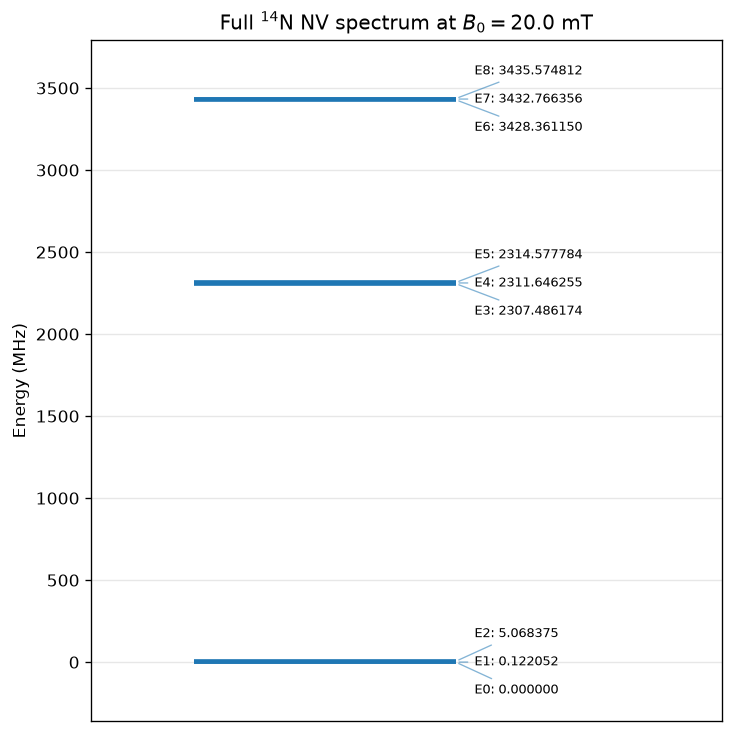

E0: 0.000000000 MHz
E1: 0.122052144 MHz
E2: 5.068374593 MHz
E3: 2307.486174195 MHz
E4: 2311.646254720 MHz
E5: 2314.577783968 MHz
E6: 3428.361149639 MHz
E7: 3432.766356438 MHz
E8: 3435.574811556 MHz


In [3]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)
plot_energy_level_diagram(
    ax,
    full_energy_levels_mhz,
    labels=[f"E{index}" for index in range(9)],
    title=rf"Full $^{{14}}$N NV spectrum at $B_0={B0_mT:.1f}$ mT",
)
plt.show()

for index, energy in enumerate(full_energy_levels_mhz):
    print(f"E{index}: {energy:.9f} MHz")

## 3. Retain the complete nine-state NV Hilbert space

The $m_s=+1$ manifold is kept in `nv.H0`; no state truncation is performed. The logical construction below still identifies the three predominantly $m_s=0$ states and the three predominantly $m_s=-1$ states, while the remaining $m_s=+1$ triplet stays available to the full laboratory-frame simulation.


In [4]:
# Keep all three electron-spin manifolds in the QuaCCAToo NV object.
retained_energy_levels_mhz = np.asarray(nv.energy_levels, dtype=float).copy()

print("Retained Hamiltonian shape:", nv.H0.shape)
print("Number of retained energy levels:", len(retained_energy_levels_mhz))

assert nv.H0.shape == (9, 9)
assert len(retained_energy_levels_mhz) == 9


Retained Hamiltonian shape: (9, 9)
Number of retained energy levels: 9


## 4. Derive the two three-state manifolds from the NV Hamiltonian

We diagonalize the complete nine-level `nv.H0`, classify its eigenstates by their $m_s=0$, $m_s=-1$, or $m_s=+1$ weight, and then label them by maximum overlap with the product states $|m_s,m_I\rangle$. This retains the small hyperfine mixing present in the physical Hamiltonian rather than assuming exact product eigenstates.

In [5]:
# Reference product states in the requested (-, 0, +) nuclear ordering.
# QuTiP orders the electron spin-1 basis as m_s=(+1,0,-1), so indices
# 1 and 2 identify the two manifolds used for the tripod construction.
ground_references = tuple(tensor(basis(3, 1), basis(3, index)) for index in (2, 1, 0))
excited_references = tuple(tensor(basis(3, 2), basis(3, index)) for index in (2, 1, 0))
state_names = ("minus", "zero", "plus")

P_ms_zero = tensor(ket2dm(basis(3, 1)), qeye(3))
P_ms_minus = tensor(ket2dm(basis(3, 2)), qeye(3))
P_ms_plus = tensor(ket2dm(basis(3, 0)), qeye(3))
eigenenergies_mhz, eigenstates = nv.H0.eigenstates()

ground_candidates = [state for state in eigenstates if expect(P_ms_zero, state) >= 0.5]
excited_candidates = [state for state in eigenstates if expect(P_ms_minus, state) > 0.5]
plus_candidates = [state for state in eigenstates if expect(P_ms_plus, state) > 0.5]

def order_states_by_reference(candidates, references):
    overlap = np.array([[abs(reference.overlap(state))**2 for state in candidates] for reference in references])
    best_order = max(permutations(range(3)), key=lambda order: sum(overlap[row, order[row]] for row in range(3)))
    return tuple(candidates[index] for index in best_order), overlap[:, best_order]

ground_states, ground_overlap = order_states_by_reference(ground_candidates, ground_references)
bare_excited_states, excited_overlap = order_states_by_reference(excited_candidates, excited_references)
ground_energies_mhz = np.array([float(expect(nv.H0, state)) for state in ground_states])
bare_excited_energies_mhz = np.array([float(expect(nv.H0, state)) for state in bare_excited_states])

print("Ground-state energies in (-, 0, +) order (MHz):", ground_energies_mhz)
print("Bare excited energies in (-, 0, +) order (MHz):", bare_excited_energies_mhz)
print("Assigned ground-state product overlaps:\n", ground_overlap)
print("Assigned excited-state product overlaps:\n", excited_overlap)
print("Number of retained m_s=+1-like eigenstates:", len(plus_candidates))
assert len(ground_states) == len(bare_excited_states) == len(plus_candidates) == 3

Ground-state energies in (-, 0, +) order (MHz): [-4.95160977 -0.00528732 -5.07366192]
Bare excited energies in (-, 0, +) order (MHz): [2302.41251228 2309.50412205 2306.5725928 ]
Assigned ground-state product overlaps:
 [[0.99999864 0.         0.        ]
 [0.         0.99999801 0.        ]
 [0.         0.         0.99999938]]
Assigned excited-state product overlaps:
 [[1.         0.         0.        ]
 [0.         0.99999864 0.        ]
 [0.         0.         0.99999863]]
Number of retained m_s=+1-like eigenstates: 3


## 5. Dress the $m_s=-1$ manifold with two RF tones

A single RF carrier does not resonantly connect all three $m_s=-1$ sublevels. We therefore use one tone for each adjacent transition. In the resonant multi-rotating frame and rotating-wave approximation,

$$H_{\mathrm{dress}}=\frac{\Omega_{\mathrm{RF}}}{2}\,P_eH_{\mathrm{RF}}P_e,$$

with only the driven transition matrix elements retained. Its nondegenerate lowest-quasienergy eigenstate is the isolated ancilla $|e\rangle$; the gap to the nearest other dressed state is $\Delta_{\mathrm{RF}}$. Here "singlet ancilla" means one isolated nondegenerate dressed state, not the NV's optical electronic singlet manifold.

### Ancilla-energy consistency check

If the returned coefficient vector $\mathbf c=(c_-,c_0,c_+)^T$ is the selected dressed eigenstate, then its expectation value must reproduce the selected rotating-frame quasienergy,

$$\langle H_{\rm dressed}\rangle_e
=\mathbf c^\dagger H_{\rm dressed}\mathbf c
=\varepsilon_e.$$

The stronger residual check $\|H_{\rm dressed}\mathbf c-\varepsilon_e\mathbf c\|=0$ verifies that the coefficients form the eigenvector itself, not merely a state with the same expectation value. These are dressed-frame quasienergy checks; they should not be interpreted as the bare laboratory-frame expectation value of `nv.H0`.


Projected RF control matrix in the supplied excited basis:
[[0.         0.99999932 0.        ]
 [0.99999932 0.         1.        ]
 [0.         1.         0.        ]]
Rotating-frame dressed Hamiltonian (MHz):
[[0.         0.74999949 0.        ]
 [0.74999949 0.         0.75      ]
 [0.         0.75       0.        ]]
Dressed quasienergies (MHz): [-1.06065981e+00  8.85606963e-17  1.06065981e+00]
Selected lowest dressed-state coefficients: [-0.49999983  0.70710678 -0.50000017]


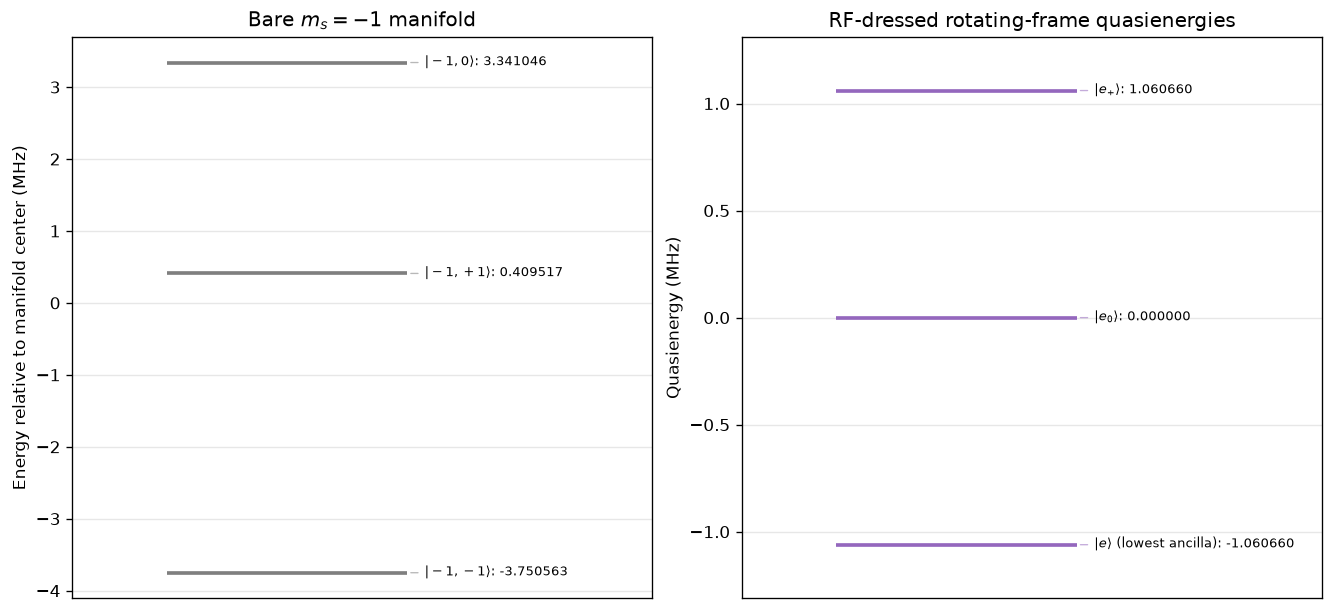

RF carrier frequencies (MHz): [7.09160977 2.93152925]
|e> coefficients in the derived (-, 0, +) basis: [-0.49999983  0.70710678 -0.50000017]
|e> quasienergy (MHz): -1.060659811
|e_0> coefficients in the derived (-, 0, +) basis: [ 7.07107022e-01  2.15105711e-16 -7.07106541e-01]
|e_0> quasienergy (MHz): 0.000000000
|e_+> coefficients in the derived (-, 0, +) basis: [0.49999983 0.70710678 0.50000017]
|e_+> quasienergy (MHz): 1.060659811
Nearest dressed-state separation Delta_RF = 1.060660 MHz
Dressed-state overlap matrix:
 [[ 1.00000000e+00  2.77555756e-16  2.77555756e-17]
 [ 2.77555756e-16  1.00000000e+00 -5.55111512e-17]
 [ 2.77555756e-17 -5.55111512e-17  1.00000000e+00]]
Dressed-projector closure error: 6.254396599051903e-16
Dressed-state quasienergies from expectation values (MHz): [-1.06065981e+00 -2.76908042e-33  1.06065981e+00]
Dressed-state eigenvector residuals (MHz): [2.71947991e-16 2.44739120e-16 1.11022302e-16]


In [6]:
rf_rabi_mhz = 1.5
rf_transition_frequencies_mhz = np.array([
    abs(bare_excited_energies_mhz[1] - bare_excited_energies_mhz[0]),
    abs(bare_excited_energies_mhz[2] - bare_excited_energies_mhz[1]),
])

(
    ancilla_coefficients,
    dressed_quasienergies_mhz,
    dressed_eigenvectors,
    projected_rf_matrix,
    H_dressed_mhz,
) = extract_ancilla_coefficients(
    nv,
    bare_excited_states,
    rf_rabi_mhz=rf_rabi_mhz,
    detunings_mhz=np.zeros(3),
    ancilla_branch="lowest",
    return_details=True,
)

# np.linalg.eigh returns the RF-dressed branches in ascending quasienergy.
# Fix each column's arbitrary global phase, then lift all three coefficient
# vectors from the projected basis back into the full nine-state NV Hilbert space.
dressed_state_coefficients = np.asarray(dressed_eigenvectors, dtype=complex).copy()
for dressed_index in range(dressed_state_coefficients.shape[1]):
    coefficients = dressed_state_coefficients[:, dressed_index]
    phase_reference = coefficients[np.argmax(np.abs(coefficients))]
    coefficients *= np.exp(-1j * np.angle(phase_reference))
    dressed_state_coefficients[:, dressed_index] = coefficients / np.linalg.norm(coefficients)

ancilla_index = int(np.argmin(dressed_quasienergies_mhz))
e_zero_index = 1
e_plus_index = int(np.argmax(dressed_quasienergies_mhz))

ancilla_coefficients = dressed_state_coefficients[:, ancilla_index]
e_zero_coefficients = dressed_state_coefficients[:, e_zero_index]
e_plus_coefficients = dressed_state_coefficients[:, e_plus_index]

dressed_excited_states = tuple(
    sum(
        coefficient * bare_state
        for coefficient, bare_state in zip(coefficients, bare_excited_states)
    ).unit()
    for coefficients in dressed_state_coefficients.T
)
excited_state = dressed_excited_states[ancilla_index]
excited_state_zero = dressed_excited_states[e_zero_index]
excited_state_plus = dressed_excited_states[e_plus_index]

# Verify all three states against the same rotating-frame dressed Hamiltonian.
dressed_state_energy_expectations_mhz = np.array([
    float(np.real(np.vdot(coefficients, H_dressed_mhz @ coefficients)))
    for coefficients in dressed_state_coefficients.T
])
dressed_state_residuals_mhz = np.array([
    np.linalg.norm(
        H_dressed_mhz @ dressed_state_coefficients[:, index]
        - dressed_quasienergies_mhz[index] * dressed_state_coefficients[:, index]
    )
    for index in range(3)
])
dressed_excited_overlap_matrix = np.array([
    [state_a.overlap(state_b) for state_b in dressed_excited_states]
    for state_a in dressed_excited_states
])
bare_excited_manifold_projector = sum(ket2dm(state) for state in bare_excited_states)
dressed_excited_manifold_projector = sum(ket2dm(state) for state in dressed_excited_states)
dressed_projector_closure_error = (
    dressed_excited_manifold_projector - bare_excited_manifold_projector
).norm()

ancilla_quasienergy_from_expectation_mhz = dressed_state_energy_expectations_mhz[ancilla_index]
ancilla_quasienergy_from_eigenvalue_mhz = float(dressed_quasienergies_mhz[ancilla_index])
ancilla_eigen_residual_mhz = float(dressed_state_residuals_mhz[ancilla_index])
delta_rf_mhz = float(dressed_quasienergies_mhz[1] - dressed_quasienergies_mhz[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
plot_rf_dressing_comparison(
    axes,
    bare_excited_energies_mhz - np.mean(bare_excited_energies_mhz),
    dressed_quasienergies_mhz,
    bare_labels=[r"$|-1,-1\rangle$", r"$|-1,0\rangle$", r"$|-1,+1\rangle$"],
    dressed_labels=[r"$|e\rangle$ (lowest ancilla)", r"$|e_{0}\rangle$", r"$|e_{+}\rangle$"],
)
plt.show()

print("RF carrier frequencies (MHz):", rf_transition_frequencies_mhz)
for label, coefficients, quasienergy in zip(
    ("e", "e_0", "e_+"),
    dressed_state_coefficients.T,
    dressed_quasienergies_mhz,
):
    print(
        f"|{label}> coefficients in the derived (-, 0, +) basis:",
        np.real_if_close(coefficients),
    )
    print(f"|{label}> quasienergy (MHz): {quasienergy:.9f}")

print(f"Nearest dressed-state separation Delta_RF = {delta_rf_mhz:.6f} MHz")
print("Dressed-state overlap matrix:\n", np.real_if_close(dressed_excited_overlap_matrix))
print("Dressed-projector closure error:", dressed_projector_closure_error)
print(
    "Dressed-state quasienergies from expectation values (MHz):",
    dressed_state_energy_expectations_mhz,
)
print("Dressed-state eigenvector residuals (MHz):", dressed_state_residuals_mhz)

assert ancilla_index == 0
assert e_zero_index == 1
assert e_plus_index == 2
assert delta_rf_mhz > 0.0
assert np.allclose(dressed_excited_overlap_matrix, np.eye(3), atol=1e-12)
assert dressed_projector_closure_error < 1e-12
assert np.allclose(
    dressed_state_energy_expectations_mhz,
    dressed_quasienergies_mhz,
    atol=1e-12,
)
assert np.max(dressed_state_residuals_mhz) < 1e-12


## 5.5 Logical tripod and higher dressed states derived from the Hamiltonian

The three low-energy eigenstates become $|g_-\rangle$, $|g_0\rangle$, and $|g_+\rangle$. Diagonalizing the RF Hamiltonian gives a complete orthonormal basis of the dressed $m_s=-1$ manifold: the lowest branch $|e\rangle$ is the intended tripod ancilla, while the middle and highest branches are denoted $|e_0\rangle$ and $|e_+\rangle$. Their projectors allow the simulations below to distinguish leakage into the two unwanted dressed branches from population retained in the four-state tripod.


In [7]:
g_minus, g_zero, g_plus = ground_states
ground_labels = (r"$P_{g_-}$", r"$P_{g_0}$", r"$P_{g_+}$")

P_g_minus, P_g_zero, P_g_plus = map(ket2dm, ground_states)
P_excited = ket2dm(excited_state)
P_excited_zero = ket2dm(excited_state_zero)
P_excited_plus = ket2dm(excited_state_plus)
P_higher_excited_total = P_excited_zero + P_excited_plus
P_ground_total = P_g_minus + P_g_zero + P_g_plus
P_tripod = P_ground_total + P_excited
P_all_states = qeye(nv.H0.dims[0])

print("Derived logical-state checks:")
for name, state, energy in zip(state_names, ground_states, ground_energies_mhz):
    print(f"  |g_{name}>: <H0> = {energy:.9f} MHz, ms=0 weight = {expect(P_ms_zero, state):.9f}")
for label, coefficients, state in zip(
    ("e", "e_0", "e_+"),
    dressed_state_coefficients.T,
    dressed_excited_states,
):
    print(f"  |{label}> coefficients:", np.real_if_close(coefficients))
    print(f"  |{label}> ms=-1 weight: {expect(P_ms_minus, state):.9f}")

assert np.allclose([[a.overlap(b) for b in ground_states] for a in ground_states], np.eye(3))
assert np.allclose(
    [[a.overlap(b) for b in dressed_excited_states] for a in dressed_excited_states],
    np.eye(3),
    atol=1e-12,
)
assert all(np.isclose(expect(P_ms_minus, state), 1.0, atol=1e-4) for state in dressed_excited_states)
assert (P_excited + P_higher_excited_total - bare_excited_manifold_projector).norm() < 1e-12


Derived logical-state checks:
  |g_minus>: <H0> = -4.951609773 MHz, ms=0 weight = 0.999998639
  |g_zero>: <H0> = -0.005287324 MHz, ms=0 weight = 0.999998009
  |g_plus>: <H0> = -5.073661917 MHz, ms=0 weight = 0.999999382
  |e> coefficients: [-0.49999983  0.70710678 -0.50000017]
  |e> ms=-1 weight: 0.999998977
  |e_0> coefficients: [ 7.07107022e-01  2.15105711e-16 -7.07106541e-01]
  |e_0> ms=-1 weight: 0.999999315
  |e_+> coefficients: [0.49999983 0.70710678 0.50000017]
  |e_+> ms=-1 weight: 0.999998977


## 5.6 Verify the effective tripod Hamiltonian against Equation (3)

The RF-dressed Hamiltonian from Section 5 is used to obtain

$$|e\rangle=\sum_{m\in\{-,0,+\}}c_m|-1,m\rangle.$$

For an approximately nuclear-spin-preserving microwave operator, the projected matrix element is

$$\langle e|H_{\rm MW}|g_m\rangle
\simeq c_m^*\langle-1,m|H_{\rm MW}|g_m\rangle.$$

Thus your proposed relation is correct if $\Omega_m^{(\rm bare)}$ already includes the bare transition matrix element and the programmed tone amplitude:

$$\widetilde\Omega_m^{(\rm projected)}
=c_m^*\Omega_m^{(\rm bare)}.$$

One notational refinement is important. Equation (3) writes a nonnegative amplitude and a separate phase,

$$H(t)=\frac{\hbar}{2}\sum_m
\left[\Omega_m^{(\rm paper)}(t)e^{-i\phi_m^{(\rm paper)}(t)}
|e\rangle\langle g_m|+\mathrm{h.c.}\right].$$

Because $c_m$ and the bare transition matrix element may be complex, `projected_mw_couplings_mhz` below is the full complex projected coupling. Its magnitude becomes $\Omega_m^{(\rm paper)}$, while its phase is combined with the programmed microwave phase. The code constructs the effective matrix once by direct assignment and again from the ket-bra sum in Equation (3), then compares every element.

In [8]:
# Peak laboratory-frame microwave scale used by the later pulse sequence.
mw_rabi_mhz = 0.08

# Bare transition matrix in the ordered (-, 0, +) manifolds. The diagonal
# entries are the approximately nuclear-spin-preserving tripod transitions.
mw_transition_matrix = np.array([
    [complex(exc.dag() * nv.MW_h1 * ground) for ground in ground_states]
    for exc in bare_excited_states
])
mw_diagonal_elements = np.diag(mw_transition_matrix)

# Project each bare transition onto |e>. This is the detailed version of
# Omega_projected_m = c_m^* Omega_bare_m: the bare coupling also contains the
# physical MW matrix element supplied by the full QuaCCAToo NV Hamiltonian.
effective_leg_elements = np.conjugate(ancilla_coefficients) * mw_diagonal_elements

# Preserve the existing pulse prescription: compensate unequal projected
# matrix-element magnitudes with relative tone weights and retain its phases.
raw_tone_weights = 1.0 / np.maximum(np.abs(effective_leg_elements), 1e-12)
mw_tone_weights = raw_tone_weights / np.max(raw_tone_weights)
mw_tone_phases = -np.angle(effective_leg_elements)

# Complex projected couplings before and after the programmed MW phase.
Omega_bare_mhz = mw_rabi_mhz * mw_tone_weights * mw_diagonal_elements
projected_mw_couplings_mhz = np.conjugate(ancilla_coefficients) * Omega_bare_mhz
tripod_complex_coefficients_mhz = (
    projected_mw_couplings_mhz * np.exp(-1j * mw_tone_phases)
)

# Translate the complex coefficients into the paper's amplitude/phase notation:
# K_m = Omega_m^(paper) exp[-i phi_m^(paper)].
Omega_paper_mhz = np.abs(tripod_complex_coefficients_mhz)
phi_paper_rad = -np.angle(tripod_complex_coefficients_mhz)

# Direct matrix representation in [|g_->, |g_0>, |g_+>, |e>].
H_tripod_from_nv_mhz = np.zeros((4, 4), dtype=complex)
for m, coefficient in enumerate(tripod_complex_coefficients_mhz):
    H_tripod_from_nv_mhz[3, m] = 0.5 * coefficient
    H_tripod_from_nv_mhz[m, 3] = 0.5 * np.conjugate(coefficient)

# Independent reconstruction of paper Eq. (3) from ket-bra outer products.
effective_basis = np.eye(4, dtype=complex)
g_basis_vectors = effective_basis[:3]
e_basis_vector = effective_basis[3]
H_equation3_mhz = np.zeros((4, 4), dtype=complex)
for m in range(3):
    ket_e_bra_gm = np.outer(e_basis_vector, np.conjugate(g_basis_vectors[m]))
    forward_term = (
        Omega_paper_mhz[m]
        * np.exp(-1j * phi_paper_rad[m])
        * ket_e_bra_gm
    )
    H_equation3_mhz += 0.5 * (forward_term + forward_term.conjugate().T)

equation3_difference_mhz = H_tripod_from_nv_mhz - H_equation3_mhz

print("Bare MW transition matrix in (-, 0, +) order:\n", mw_transition_matrix)
print("\nProjected complex MW couplings (MHz):", projected_mw_couplings_mhz)
print("Paper Omega_m amplitudes (MHz):", Omega_paper_mhz)
print("Paper phi_m phases (rad):", phi_paper_rad)
print("\nTripod Hamiltonian derived from the full NV model (MHz):\n", H_tripod_from_nv_mhz)
print("\nTripod Hamiltonian reconstructed from Eq. (3) (MHz):\n", H_equation3_mhz)
print("\nMaximum elementwise difference (MHz):", np.max(np.abs(equation3_difference_mhz)))

# Verify the factor 1/2, phase convention, Hermitian conjugates, basis order,
# and the absence of direct ground-to-ground or ancilla diagonal couplings.
assert np.allclose(H_tripod_from_nv_mhz, H_equation3_mhz, atol=1e-14)
assert np.allclose(H_equation3_mhz, H_equation3_mhz.conjugate().T)
assert np.allclose(H_equation3_mhz[:3, :3], 0.0)
assert np.isclose(H_equation3_mhz[3, 3], 0.0)

print("\nPASS: the projected full-NV microwave couplings reproduce paper Equation (3).")


Bare MW transition matrix in (-, 0, +) order:
 [[ 9.99999320e-01+0.j  0.00000000e+00+0.j  0.00000000e+00+0.j]
 [ 0.00000000e+00+0.j  9.99997405e-01+0.j  0.00000000e+00+0.j]
 [-4.18463760e-06+0.j  0.00000000e+00+0.j  9.99998086e-01+0.j]]

Projected complex MW couplings (MHz): [-0.03999994+4.89857949e-18j  0.03999994-4.89857949e-18j
 -0.03999994+4.89857949e-18j]
Paper Omega_m amplitudes (MHz): [0.03999994 0.03999994 0.03999994]
Paper phi_m phases (rad): [2.4492936e-16 2.4492936e-16 2.4492936e-16]

Tripod Hamiltonian derived from the full NV model (MHz):
 [[0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.01999997+4.89857949e-18j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.01999997+4.89857949e-18j]
 [0.        +0.00000000e+00j 0.        +0.00000000e+00j
  0.        +0.00000000e+00j 0.01999997+4.89857949e-18j]
 [0.01999997-4.89857949e-18j 0.01999997-4.89857949e-18j
  0.01999997-4.89857949e-18j 0.        +0.0000

## 6. Continuous RF dressing followed by microwave pumping

The RF envelope ramps on first and remains on throughout the sequence. After the dressed basis is established, three phase-coherent microwave tones begin. Their carrier frequencies address the three derived ground-to-excited lines, and their amplitudes compensate the MW matrix elements and ancilla coefficients so that the effective tripod legs are approximately balanced. The full nine-state laboratory Hamiltonian is then evolved by QuaCCAToo.

The calculation is shown in three stages: the applied control amplitudes, the duration-swept `Rabi` experiment, and an independent stepped `PulsedSim` evolution using the same full nine-state system, control Hamiltonians, carrier-resolved pulse functions, and solver tolerances.


### 6.1 RF and three-tone microwave controls

The plot shows slowly varying drive-envelope amplitudes so the timing and relative tone strengths remain readable. The GHz/MHz carrier oscillations are retained in `rf_dressing_pulse` and `microwave_pulse` during simulation but are intentionally not drawn over the full eight-microsecond window.

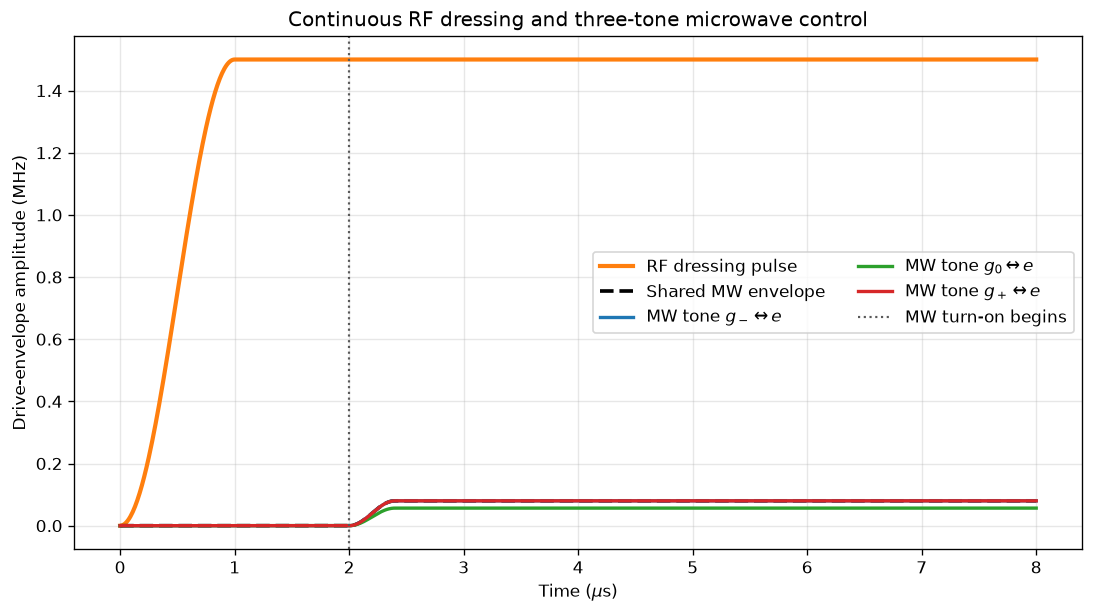

RF tones (MHz): [7.09160977 2.93152925]
MW tones (MHz): [2306.30346224 2308.44874956 2310.58559491]
MW relative tone weights: [0.99999945 0.7071075  1.        ]
MW tone phases (rad): [-3.14159265e+00  1.22464680e-16 -3.14159265e+00]


In [9]:
total_time_us = 8.0
rf_ramp_time_us = 1.0
mw_start_time_us = 2.0
mw_ramp_time_us = 0.4
pulse_times_us = np.linspace(0.0, total_time_us, 801)

def solver_to_physical_time_us(t):
    return np.asarray(t) / (2.0 * np.pi)

def sin2_turn_on(time_us, start_us, ramp_us):
    x = np.clip((np.asarray(time_us) - start_us) / ramp_us, 0.0, 1.0)
    return np.sin(0.5 * np.pi * x)**2

def rf_envelope(time_us):
    return sin2_turn_on(time_us, 0.0, rf_ramp_time_us)

def mw_envelope(time_us):
    return sin2_turn_on(time_us, mw_start_time_us, mw_ramp_time_us)

def rf_dressing_pulse(t, **kwargs):
    time_us = solver_to_physical_time_us(t)
    carriers = sum(np.cos(frequency * t) for frequency in rf_transition_frequencies_mhz)
    return rf_envelope(time_us) * carriers

# Reuse the microwave matrix elements, balancing weights, and phases
# that were explicitly verified against Equation (3) above.
ancilla_shift_mhz = float(dressed_quasienergies_mhz[ancilla_index])
mw_transition_frequencies_mhz = np.abs(bare_excited_energies_mhz - ground_energies_mhz) + ancilla_shift_mhz

def microwave_pulse(t, **kwargs):
    time_us = solver_to_physical_time_us(t)
    carriers = sum(
        weight * np.cos(frequency * t + phase)
        for weight, frequency, phase in zip(
            mw_tone_weights, mw_transition_frequencies_mhz, mw_tone_phases
        )
    )
    return mw_envelope(time_us) * carriers

# Display the slowly varying drive amplitudes. The laboratory simulation below
# still uses the carrier-resolved rf_dressing_pulse and microwave_pulse functions.
rf_drive_envelope_mhz = rf_rabi_mhz * rf_envelope(pulse_times_us)
mw_shared_envelope_mhz = mw_rabi_mhz * mw_envelope(pulse_times_us)
mw_tone_envelopes_mhz = np.array([
    mw_rabi_mhz * weight * mw_envelope(pulse_times_us)
    for weight in mw_tone_weights
])

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
ax.plot(
    pulse_times_us, rf_drive_envelope_mhz,
    lw=2.5, color="tab:orange", label="RF dressing pulse",
)
ax.plot(
    pulse_times_us, mw_shared_envelope_mhz,
    lw=2.2, color="black", ls="--", label="Shared MW envelope",
)
for tone_envelope, label, color in zip(
    mw_tone_envelopes_mhz,
    (r"MW tone $g_-\leftrightarrow e$", r"MW tone $g_0\leftrightarrow e$", r"MW tone $g_+\leftrightarrow e$"),
    ("tab:blue", "tab:green", "tab:red"),
):
    ax.plot(pulse_times_us, tone_envelope, lw=2.0, color=color, label=label)
ax.axvline(mw_start_time_us, color="0.35", ls=":", lw=1.3, label="MW turn-on begins")
ax.set(
    xlabel=r"Time ($\mu$s)",
    ylabel="Drive-envelope amplitude (MHz)",
    title="Continuous RF dressing and three-tone microwave control",
)
ax.legend(ncol=2)
plt.show()

print("RF tones (MHz):", rf_transition_frequencies_mhz)
print("MW tones (MHz):", mw_transition_frequencies_mhz)
print("MW relative tone weights:", mw_tone_weights)
print("MW tone phases (rad):", mw_tone_phases)

#### Interpreting the drive-amplitude plot

The RF dressing pulse ramps on first and remains at constant amplitude, establishing the dressed $m_s=-1$ basis before microwave pumping begins. The dashed black line is the shared MW turn-on envelope. The three colored MW traces include their independently calibrated tone weights; their unequal bare amplitudes compensate the ancilla coefficients and transition matrix elements so that the projected tripod couplings are balanced.

### 6.2 QuaCCAToo `Rabi` duration sweep

`Rabi` integrates the complete carrier-resolved Hamiltonian once over `pulse_times_us`. Its stored states provide the population at every pulse duration, producing the reference oscillation curves below.

Maximum normalization error: 6.661e-16
Maximum selected ancilla population: 0.303406
Minimum total ground population: 0.656614



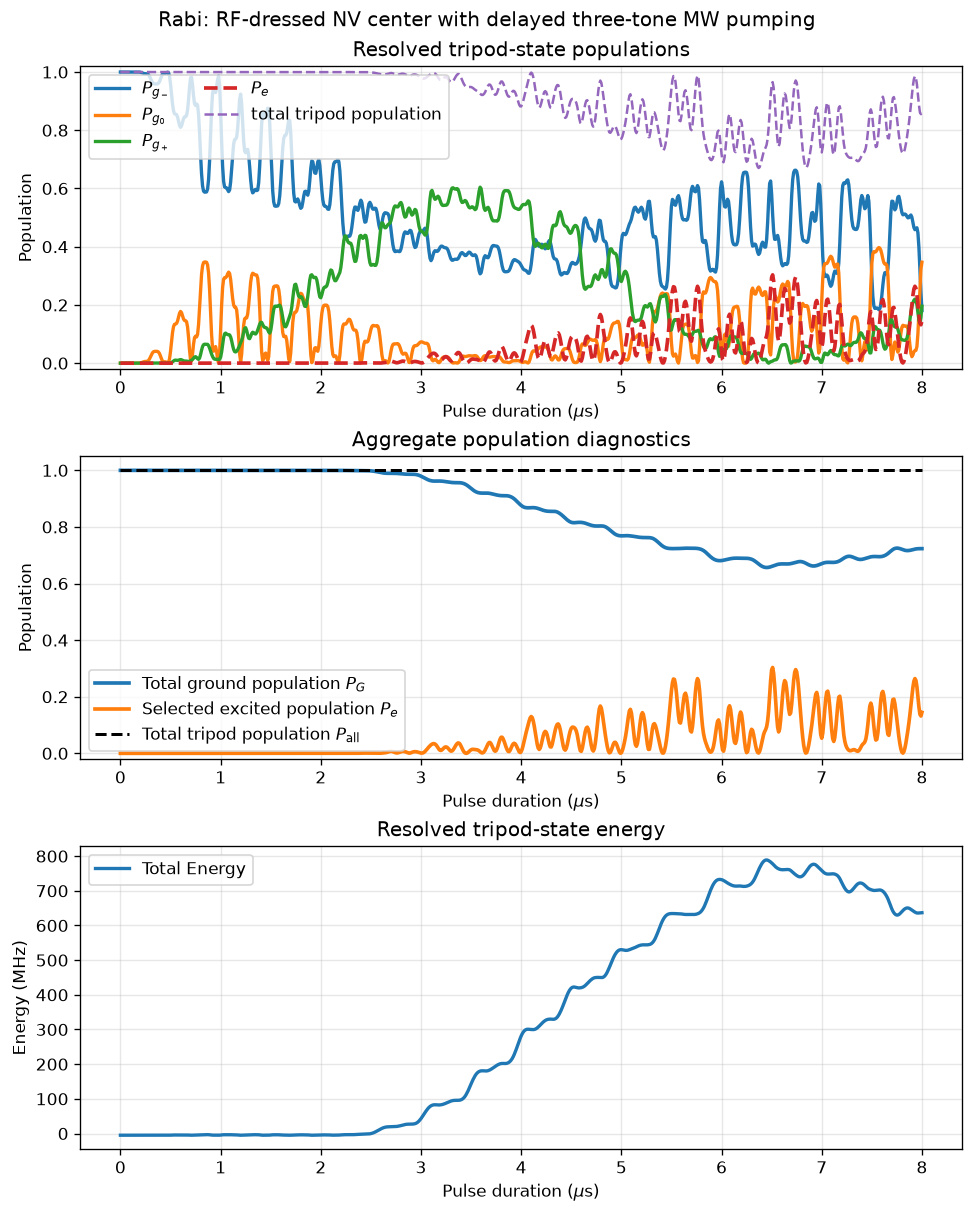

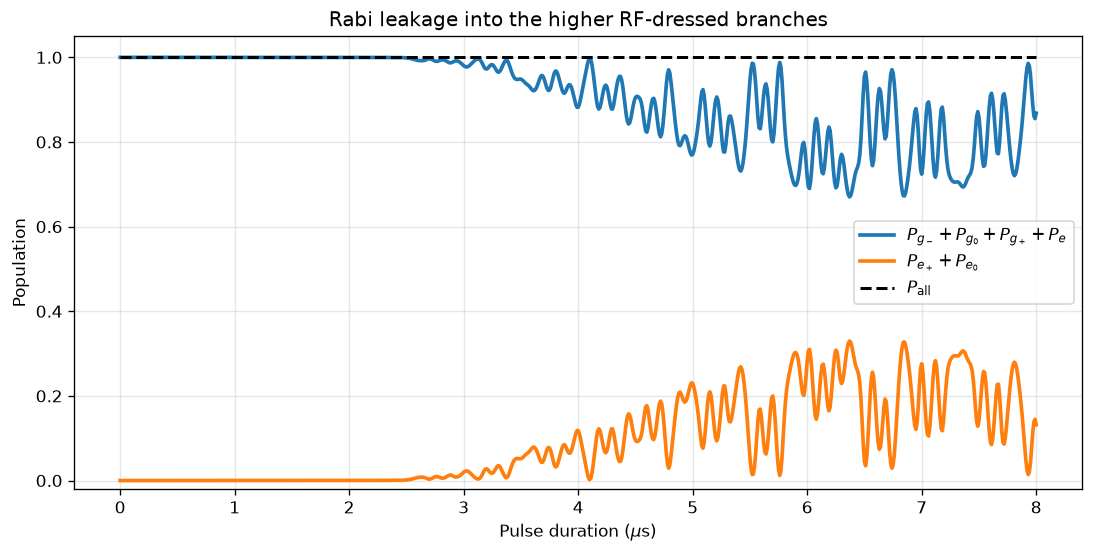

Maximum normalization error: 6.661e-16
Maximum dressed-ancilla population: 0.303406
Maximum higher-dressed leakage: 0.329711


In [10]:
nv.rho0 = g_minus
nv.observable = [
    P_g_minus, P_g_zero, P_g_plus, P_excited,
    P_excited_zero, P_excited_plus,
    P_ground_total, P_all_states, nv.H0,
]

dressed_nv_rabi = Rabi(
    pulse_duration=pulse_times_us,
    system=nv,
    h1=[rf_rabi_mhz * nv.RF_h1, mw_rabi_mhz * nv.MW_h1],
    pulse_shape=[rf_dressing_pulse, microwave_pulse],
    options={"nsteps": 500000, "atol": 1e-9, "rtol": 1e-7},
)
dressed_nv_rabi.run()

rabi_results = [np.asarray(result) for result in dressed_nv_rabi.results]
rabi_population_indices = (0, 1, 2, 3, 6, 7)
rabi_population_results = [rabi_results[index] for index in rabi_population_indices]
rabi_e_zero_population = rabi_results[4]
rabi_e_plus_population = rabi_results[5]
rabi_higher_dressed_population = rabi_e_zero_population + rabi_e_plus_population
rabi_tripod_population = rabi_results[6] + rabi_results[3]
rabi_total_energy_mhz = rabi_results[8]

fig, axes = plot_rabi_diagnostics(
    dressed_nv_rabi.variable,
    rabi_population_results,
    ground_labels,
    rabi_total_energy_mhz,
)
fig.suptitle("Rabi: RF-dressed NV center with delayed three-tone MW pumping")
plt.show()

fig_leakage, ax_leakage = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
plot_tripod_leakage(
    ax_leakage,
    dressed_nv_rabi.variable,
    rabi_tripod_population,
    rabi_higher_dressed_population,
    rabi_results[7],
    title="Rabi leakage into the higher RF-dressed branches",
)
plt.show()

P_all_t = rabi_population_results[5]
print(f"Maximum normalization error: {np.max(np.abs(P_all_t - 1.0)):.3e}")
print(f"Maximum dressed-ancilla population: {np.max(rabi_population_results[3]):.6f}")
print(f"Maximum higher-dressed leakage: {np.max(rabi_higher_dressed_population):.6f}")

#### Interpreting the Rabi leakage plot

The intended tripod population includes all three $m_s=0$ ground states and the selected lowest dressed ancilla $|e\rangle$. Its loss is compared directly with population accumulated in the two unwanted RF-dressed branches $|e_0\rangle$ and $|e_+\rangle$. The all-state trace remains one. Any residual gap between the first two curves and $P_{\rm all}$ represents the three remaining $m_s=+1$-like states retained by the full model.


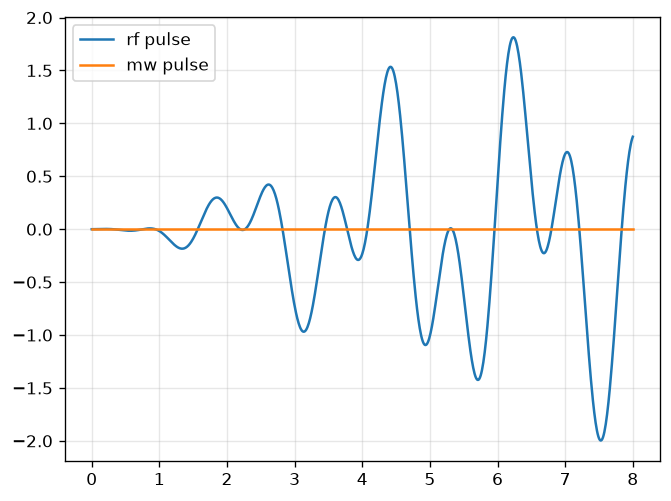

In [11]:
t = np.linspace(0, 8, 801)
rf_pulse_plot = rf_dressing_pulse(t)
mw_pulse_plot = microwave_pulse(t)

plt.plot(t, rf_pulse_plot, label='rf pulse')
plt.plot(t, mw_pulse_plot, label='mw pulse')
plt.legend()

### 6.3 `PulsedSim` population comparison

`PulsedSim.add_pulse` returns the state at the end of a pulse segment. To obtain a trajectory without changing QuaCCAToo internals, the same eight-microsecond pulse is divided into consecutive reporting segments. The state is carried continuously from one segment to the next, and no projective measurements are made.

The comparison uses the same `nv.H0`, initial state, observables, RF/MW control operators, carrier frequencies, envelopes, and solver tolerances as the `Rabi` calculation. Restarting the carrier-resolved integrator at reporting boundaries introduces a small numerical discrepancy, which is plotted explicitly below.


In [12]:
# Use one sequential PulsedSim experiment with forty reporting segments.
pulsedsim_times_us = np.linspace(0.0, total_time_us, 801)
pulsedsim_observable_results = np.empty((9, len(pulsedsim_times_us)), dtype=float)

nv.rho0 = g_minus
dressed_nv_pulsedsim = PulsedSim(nv)
population_observables = [
    P_g_minus, P_g_zero, P_g_plus, P_excited,
    P_excited_zero, P_excited_plus,
    P_ground_total, P_all_states, nv.H0,
]
pulsedsim_observable_results[:, 0] = [
    float(np.real(expect(observable, dressed_nv_pulsedsim.rho)))
    for observable in population_observables
]

for time_index in range(1, len(pulsedsim_times_us)):
    segment_duration_us = float(
        pulsedsim_times_us[time_index] - pulsedsim_times_us[time_index - 1]
    )
    dressed_nv_pulsedsim.add_pulse(
        duration=segment_duration_us,
        h1=[rf_rabi_mhz * nv.RF_h1, mw_rabi_mhz * nv.MW_h1],
        pulse_shape=[rf_dressing_pulse, microwave_pulse],
        pulse_params={},
        time_steps=4,
        options={"nsteps": 500000, "atol": 1e-9, "rtol": 1e-7},
    )
    pulsedsim_observable_results[:, time_index] = [
        float(np.real(expect(observable, dressed_nv_pulsedsim.rho)))
        for observable in population_observables
    ]

pulsedsim_population_indices = (0, 1, 2, 3, 6, 7)
pulsedsim_population_results = pulsedsim_observable_results[list(pulsedsim_population_indices)]
pulsedsim_e_zero_population = pulsedsim_observable_results[4]
pulsedsim_e_plus_population = pulsedsim_observable_results[5]
pulsedsim_higher_dressed_population = (
    pulsedsim_e_zero_population + pulsedsim_e_plus_population
)
pulsedsim_tripod_population = (
    pulsedsim_observable_results[6] + pulsedsim_observable_results[3]
)
pulsedsim_total_energy_mhz = pulsedsim_observable_results[8]

# Sample the dense Rabi trajectories at the PulsedSim reporting times.
rabi_observables_at_pulsedsim_times = np.vstack([
    np.interp(pulsedsim_times_us, dressed_nv_rabi.variable, observable_result)
    for observable_result in rabi_results
])
population_difference = (
    pulsedsim_population_results
    - rabi_observables_at_pulsedsim_times[list(rabi_population_indices)]
)
energy_difference_mhz = (
    pulsedsim_total_energy_mhz - rabi_observables_at_pulsedsim_times[8]
)
max_rabi_pulsedsim_difference = float(np.max(np.abs(population_difference)))

print("Maximum |PulsedSim - Rabi| population difference:", max_rabi_pulsedsim_difference)
print(
    "Maximum Rabi ancilla population on the PulsedSim grid:",
    np.max(rabi_observables_at_pulsedsim_times[3]),
)
print(
    "Maximum PulsedSim ancilla population on the same grid:",
    np.max(pulsedsim_population_results[3]),
)
print(
    "PulsedSim maximum normalization error:",
    np.max(np.abs(pulsedsim_population_results[5] - 1.0)),
)
print(
    "Maximum |PulsedSim - Rabi| energy difference (MHz):",
    np.max(np.abs(energy_difference_mhz)),
)

assert np.allclose(pulsedsim_population_results[5], 1.0, atol=1e-6)
assert max_rabi_pulsedsim_difference < 2e-2


Maximum |PulsedSim - Rabi| population difference: 0.014888161376165665
Maximum Rabi ancilla population on the PulsedSim grid: 0.3034055638840071
Maximum PulsedSim ancilla population on the same grid: 0.30986752985340527
PulsedSim maximum normalization error: 6.661338147750939e-16
Maximum |PulsedSim - Rabi| energy difference (MHz): 21.63815453401969


### 6.4 Standalone `PulsedSim` population result

This figure shows the population trajectory returned by the segmented `PulsedSim` evolution on its own, before overlaying it with the denser `Rabi` result.


Maximum normalization error: 6.661e-16
Maximum selected ancilla population: 0.309868
Minimum total ground population: 0.650222



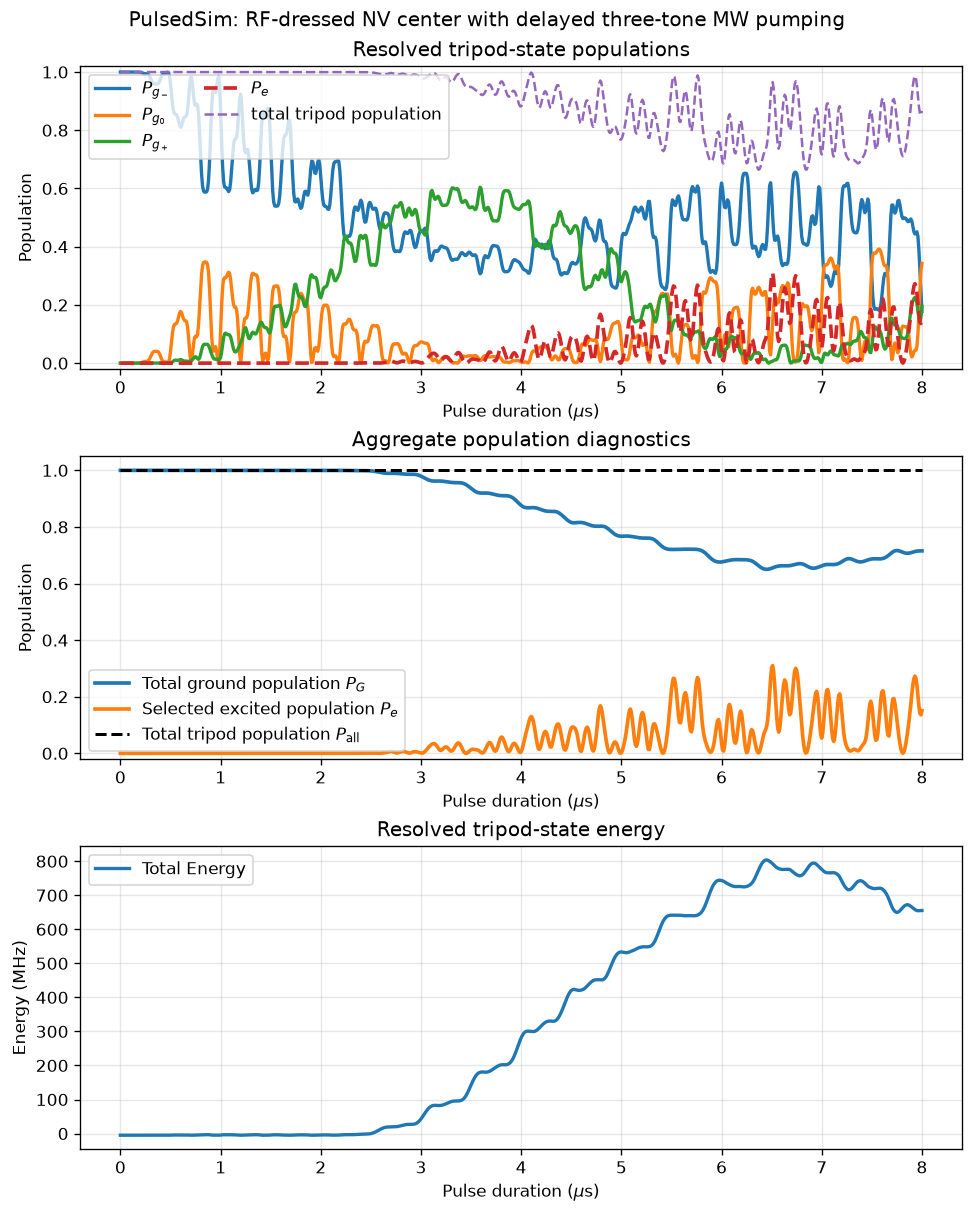

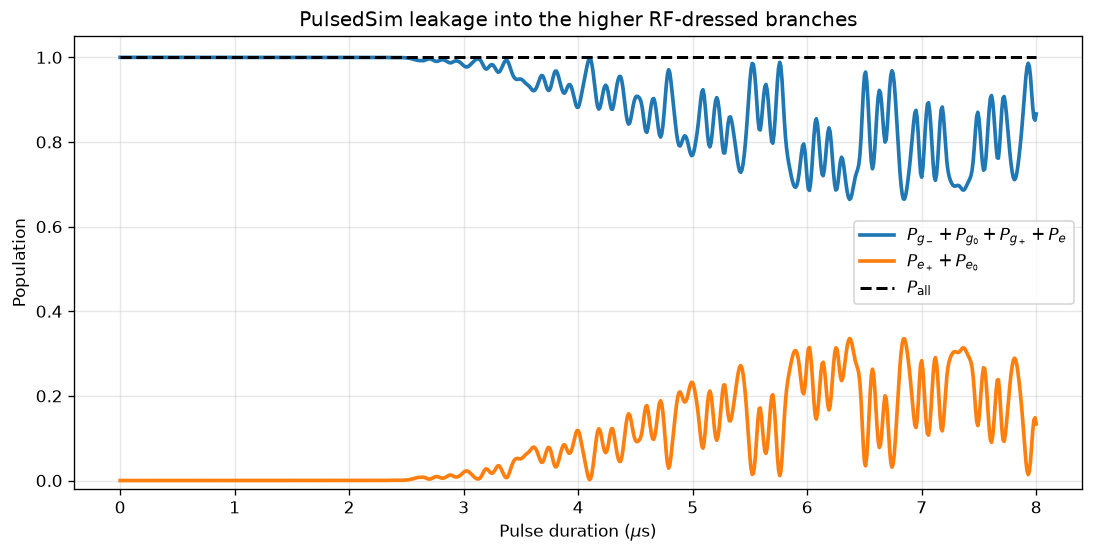

Maximum PulsedSim normalization error: 6.661e-16
Maximum PulsedSim dressed-ancilla population: 0.309868
Maximum PulsedSim higher-dressed leakage: 0.335650


In [13]:
fig, axes = plot_rabi_diagnostics(
    pulsedsim_times_us,
    pulsedsim_population_results,
    ground_labels,
    pulsedsim_total_energy_mhz,
)
fig.suptitle("PulsedSim: RF-dressed NV center with delayed three-tone MW pumping")
plt.show()

fig_leakage, ax_leakage = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
plot_tripod_leakage(
    ax_leakage,
    pulsedsim_times_us,
    pulsedsim_tripod_population,
    pulsedsim_higher_dressed_population,
    pulsedsim_population_results[5],
    title="PulsedSim leakage into the higher RF-dressed branches",
)
plt.show()

print(
    f"Maximum PulsedSim normalization error: "
    f"{np.max(np.abs(pulsedsim_population_results[5] - 1.0)):.3e}"
)
print(
    f"Maximum PulsedSim dressed-ancilla population: "
    f"{np.max(pulsedsim_population_results[3]):.6f}"
)
print(
    f"Maximum PulsedSim higher-dressed leakage: "
    f"{np.max(pulsedsim_higher_dressed_population):.6f}"
)


#### Interpreting the `PulsedSim` populations

The initial state is $|g_-\rangle$, so the RF field alone does not move population before the microwave envelope begins: it dresses the $m_s=-1$ manifold while the state remains in $m_s=0$. Once the three microwave tones turn on, population oscillates through the selected dressed ancilla and can return into all three tripod ground states. The all-state trace remains one; any difference between the summed tripod population and one represents occupation outside the four-state tripod subspace, not loss of normalization.

In the additional leakage panel, the first curve is the complete intended four-state tripod population, while the second is the combined population of $|e_0\rangle$ and $|e_+\rangle$. The gap between their sum and $P_{\rm all}$ can only occupy the remaining three $m_s=+1$-like states of the full nine-level model.


### 6.5 Direct `Rabi`–`PulsedSim` comparison

The upper panel overlays the optimized continuous `Rabi` trajectory with the endpoints obtained from `PulsedSim`. The lower panel isolates the absolute numerical difference for each tripod state.


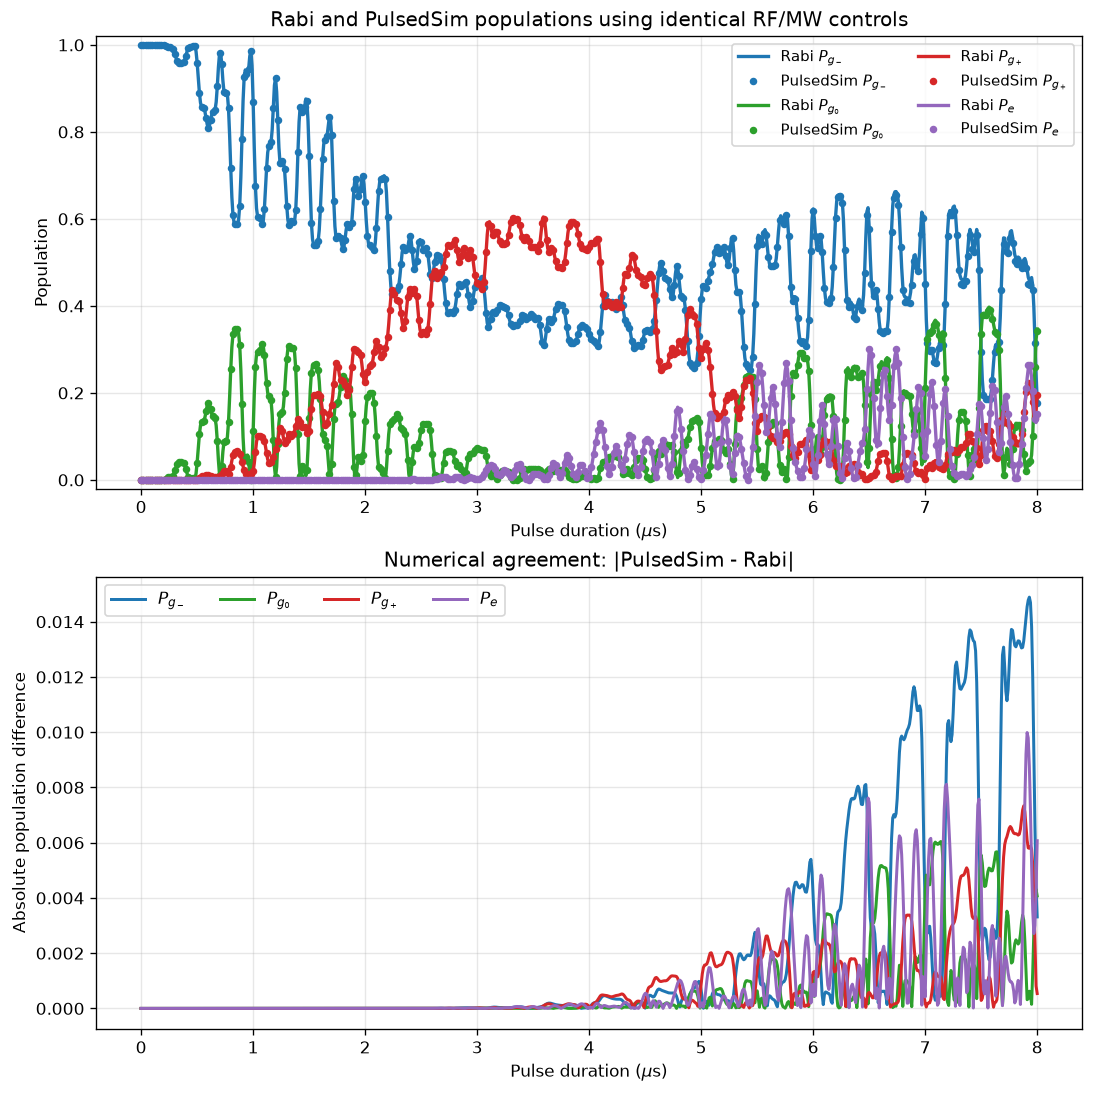

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(9, 9), constrained_layout=True)
comparison_labels = (r"$P_{g_-}$", r"$P_{g_0}$", r"$P_{g_+}$", r"$P_e$")
comparison_colors = ("tab:blue", "tab:green", "tab:red", "tab:purple")

for state_index, (label, color) in enumerate(zip(comparison_labels, comparison_colors)):
    axes[0].plot(
        dressed_nv_rabi.variable,
        rabi_population_results[state_index],
        color=color,
        lw=2,
        label=f"Rabi {label}",
    )
    axes[0].plot(
        pulsedsim_times_us,
        pulsedsim_population_results[state_index],
        color=color,
        marker="o",
        ms=3.5,
        ls="none",
        markevery=2,
        label=f"PulsedSim {label}",
    )

axes[0].set(
    xlabel=r"Pulse duration ($\mu$s)",
    ylabel="Population",
    ylim=(-0.02, 1.02),
    title="Rabi and PulsedSim populations using identical RF/MW controls",
)
axes[0].legend(ncol=2, fontsize=9)

for state_index, (label, color) in enumerate(zip(comparison_labels, comparison_colors)):
    axes[1].plot(
        pulsedsim_times_us,
        np.abs(population_difference[state_index]),
        color=color,
        lw=1.8,
        label=label,
    )
axes[1].set(
    xlabel=r"Pulse duration ($\mu$s)",
    ylabel="Absolute population difference",
    title="Numerical agreement: |PulsedSim - Rabi|",
)
axes[1].legend(ncol=4)
plt.show()


## 7. Complete loop-order pulse implementation

### Sequence overview and ordering convention

This section implements both chronological orders of the non-Abelian phase loops while explicitly retaining the RF and microwave turn-on and turn-off stages. A tuple such as `("C1", "C2")` is chronological: $C_1$ is performed first, followed by $C_2$, so the resulting state transformation is $U(C_2)U(C_1)$. The reversed tuple implements $U(C_1)U(C_2)$.

The controls follow this schedule for both orderings:

| Time interval | RF dressing | Three MW legs | Phase operation |
|---|---|---|---|
| $0$–$4\,\mu\mathrm{s}$ | Smooth $\sin^2$ ramp on | Off | None |
| $4$–$6\,\mu\mathrm{s}$ | Fully on | Off | RF-dressed basis settles |
| $6$–$12\,\mu\mathrm{s}$ | Fully on | Smooth $\sin^2$ ramp on | Initial tripod phases fixed |
| $12$–$92\,\mu\mathrm{s}$ | Fully on | Fully on | First loop in the selected order |
| $92$–$172\,\mu\mathrm{s}$ | Fully on | Fully on | Second loop in the selected order |
| $172$–$178\,\mu\mathrm{s}$ | Fully on | Smooth $\cos^2$ ramp to zero | Loops complete |
| $178$–$182\,\mu\mathrm{s}$ | Smooth $\cos^2$ ramp to zero | Zero | Adiabatic RF removal |
| $t\ge182\,\mu\mathrm{s}$ | Zero | Zero | Final state available for readout |

The RF field therefore remains on throughout both loops, and the three MW amplitudes remain on while their phases execute Equation (10). Neither drive is interrupted at the boundary between $C_1$ and $C_2$. The MW fields are removed before the RF field so that the tripod coupling closes before the dressed basis is removed.

### Modeling convention

The calculation uses QuaCCAToo `PulsedSim` in the complete nine-state NV Hilbert space, but in the resonant multi-rotating frame. The projected RF Hamiltonian from Section 5 is embedded back into the nine-state space, and the three MW controls couple each derived ground state to its corresponding bare $m_s=-1$ state. This retains $|e\rangle$, $|e_0\rangle$, $|e_+\rangle$, and the three spectator $m_s=+1$-like states while avoiding an unnecessarily expensive $2.3$ GHz carrier-resolved integration over hundreds of microseconds. All amplitudes and phases remain explicit and editable below.


In [15]:
# -----------------------------------------------------------------------------
# A. Editable sequence times and smooth turn-on/turn-off envelopes
# -----------------------------------------------------------------------------
rf_loop_ramp_us = 4.0
rf_settle_us = 2.0
mw_loop_ramp_us = 6.0
berry_loop_duration_us = 80.0
loop_reporting_step_us = 0.5

t_rf_ramp_start_us = 0.0
t_rf_on_us = t_rf_ramp_start_us + rf_loop_ramp_us
t_mw_ramp_start_us = t_rf_on_us + rf_settle_us
t_loop_1_start_us = t_mw_ramp_start_us + mw_loop_ramp_us
t_loop_2_start_us = t_loop_1_start_us + berry_loop_duration_us
t_mw_ramp_down_start_us = t_loop_2_start_us + berry_loop_duration_us
t_mw_zero_us = t_mw_ramp_down_start_us + mw_loop_ramp_us
t_rf_ramp_down_start_us = t_mw_zero_us
t_rf_zero_us = t_rf_ramp_down_start_us + rf_loop_ramp_us
loop_sequence_duration_us = t_rf_zero_us


def sin2_ramp_fraction(time_us, start_us, duration_us):
    """Evaluate a smooth zero-to-one sin-squared ramp.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Physical time in microseconds.
    start_us : float
        Time at which the ramp begins at zero.
    duration_us : float
        Positive ramp duration in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Dimensionless ramp fraction between zero and one. The endpoint slopes
        vanish, which reduces nonadiabatic excitation from abrupt switching.
    """
    scaled_time = np.clip((np.asarray(time_us) - start_us) / duration_us, 0.0, 1.0)
    return np.sin(0.5 * np.pi * scaled_time)**2


def rf_loop_envelope(time_us):
    """Return the dimensionless RF amplitude for the complete loop sequence.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Physical time in microseconds.

    Returns
    -------
    float or numpy.ndarray
        RF amplitude fraction: smooth turn-on, unity during MW preparation and
        both loops, then a smooth turn-off after the MW amplitude reaches zero.
    """
    time_array = np.asarray(time_us)
    ramp_up = sin2_ramp_fraction(time_array, t_rf_ramp_start_us, rf_loop_ramp_us)
    ramp_down = 1.0 - sin2_ramp_fraction(
        time_array, t_rf_ramp_down_start_us, rf_loop_ramp_us
    )
    envelope = np.where(
        time_array < t_rf_on_us,
        ramp_up,
        np.where(
            time_array < t_rf_ramp_down_start_us,
            1.0,
            np.where(time_array < t_rf_zero_us, ramp_down, 0.0),
        ),
    )
    return float(envelope) if envelope.ndim == 0 else envelope


def mw_loop_envelope(time_us):
    """Return the shared dimensionless MW amplitude for the full sequence.

    Parameters
    ----------
    time_us : float or numpy.ndarray
        Physical time in microseconds.

    Returns
    -------
    float or numpy.ndarray
        MW amplitude fraction: zero during RF preparation, smooth turn-on,
        unity throughout both loops, and smooth turn-off before RF removal.
    """
    time_array = np.asarray(time_us)
    ramp_up = sin2_ramp_fraction(time_array, t_mw_ramp_start_us, mw_loop_ramp_us)
    ramp_down = 1.0 - sin2_ramp_fraction(
        time_array, t_mw_ramp_down_start_us, mw_loop_ramp_us
    )
    envelope = np.where(
        time_array < t_mw_ramp_start_us,
        0.0,
        np.where(
            time_array < t_loop_1_start_us,
            ramp_up,
            np.where(
                time_array < t_mw_ramp_down_start_us,
                1.0,
                np.where(time_array < t_mw_zero_us, ramp_down, 0.0),
            ),
        ),
    )
    return float(envelope) if envelope.ndim == 0 else envelope


def berry_phase_winding(local_time_us, duration_us):
    """Evaluate the smooth 0-to-2pi phase winding from paper Equation (10).

    Parameters
    ----------
    local_time_us : float or numpy.ndarray
        Time measured from the beginning of the active loop.
    duration_us : float
        Loop duration in microseconds.

    Returns
    -------
    float or numpy.ndarray
        Phase in radians with zero derivative at both endpoints.
    """
    local_time_us = np.clip(np.asarray(local_time_us), 0.0, duration_us)
    return 2.0 * np.pi * np.sin(np.pi * local_time_us / (2.0 * duration_us))**2


loop_leg_index = {"C1": 0, "C2": 2}  # C1 winds phi_-; C2 winds phi_+.


def loop_phase_vector(time_us, loop_order):
    """Return the three effective MW phase windings at one physical time.

    Parameters
    ----------
    time_us : float
        Absolute sequence time in microseconds.
    loop_order : tuple of str
        Chronological pair, either ('C1','C2') or ('C2','C1').

    Returns
    -------
    numpy.ndarray, shape (3,)
        Additional phases [phi_-, phi_0, phi_+] in radians. Only the leg
        selected by the currently active loop is wound.
    """
    if tuple(loop_order) not in (("C1", "C2"), ("C2", "C1")):
        raise ValueError("loop_order must be ('C1','C2') or ('C2','C1')")

    phases = np.zeros(3, dtype=float)
    if t_loop_1_start_us <= time_us < t_loop_2_start_us:
        loop_name = loop_order[0]
        phases[loop_leg_index[loop_name]] = berry_phase_winding(
            time_us - t_loop_1_start_us, berry_loop_duration_us
        )
    elif t_loop_2_start_us <= time_us < t_mw_ramp_down_start_us:
        loop_name = loop_order[1]
        phases[loop_leg_index[loop_name]] = berry_phase_winding(
            time_us - t_loop_2_start_us, berry_loop_duration_us
        )
    return phases


def loop_sequence_events(loop_order):
    """Describe the event markers used on the envelope and population plots.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological phase-loop order.

    Returns
    -------
    list of tuple
        Entries (time_us, label, color) for RF/MW switching, both loop starts,
        and the times at which the MW and RF amplitudes reach zero.
    """
    return [
        (t_rf_ramp_start_us, "RF ramp-up starts", "tab:orange"),
        (t_rf_on_us, "RF on", "tab:orange"),
        (t_mw_ramp_start_us, "MW ramp-up starts", "tab:blue"),
        (t_loop_1_start_us, f"MW on / {loop_order[0]} starts", "tab:purple"),
        (t_loop_2_start_us, f"{loop_order[1]} starts", "tab:pink"),
        (t_mw_ramp_down_start_us, "MW ramp-down starts", "tab:blue"),
        (t_mw_zero_us, "MW = 0 / RF ramp-down starts", "tab:orange"),
        (t_rf_zero_us, "RF = 0", "black"),
    ]


def mark_loop_sequence_events(ax, loop_order, annotate=True):
    """Add switching and loop-start markers to a time-domain axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Population, leakage, envelope, or phase axes to annotate.
    loop_order : tuple of str
        Chronological phase-loop order determining the loop-start labels.
    annotate : bool
        If True, print vertical event labels at the top of the axes.

    Returns
    -------
    matplotlib.axes.Axes
        The supplied axes with vertical event markers added.
    """
    for event_index, (event_time, label, color) in enumerate(loop_sequence_events(loop_order)):
        ax.axvline(event_time, color=color, ls=":", lw=1.0, alpha=0.75)
        if annotate:
            vertical_position = 0.98 - 0.08 * (event_index % 2)
            ax.text(
                event_time,
                vertical_position,
                label,
                color=color,
                rotation=90,
                va="top",
                ha="right",
                fontsize=7.5,
                transform=ax.get_xaxis_transform(),
            )
    return ax


# -----------------------------------------------------------------------------
# B. Embed the RF and MW rotating-frame controls in the full nine-state space
# -----------------------------------------------------------------------------
def embed_matrix_in_state_basis(matrix, states, template_operator):
    """Lift a matrix representation into the Hilbert space spanned by states.

    Parameters
    ----------
    matrix : numpy.ndarray, shape (N,N)
        Operator matrix in the ordered basis supplied by `states`.
    states : sequence of qutip.Qobj
        Orthonormal kets defining the projected basis.
    template_operator : qutip.Qobj
        Full-space operator used to preserve QuaCCAToo/QuTiP dimensions.

    Returns
    -------
    qutip.Qobj
        Full-Hilbert-space operator with the requested projected matrix.
    """
    matrix = np.asarray(matrix, dtype=complex)
    if matrix.shape != (len(states), len(states)):
        raise ValueError("matrix shape must match the number of basis states")
    embedded = 0.0 * template_operator
    for row, bra_state in enumerate(states):
        for column, ket_state in enumerate(states):
            embedded += matrix[row, column] * bra_state * ket_state.dag()
    return embedded


# Shift the excited rotating frame so the selected lowest dressed branch is
# resonant at full RF amplitude. The higher branches then lie at Delta_RF and
# 2*Delta_RF, while the RF is explicitly ramped by H_rf_loop_control_mhz.
H_loop_static_mhz = (
    -ancilla_quasienergy_from_eigenvalue_mhz * bare_excited_manifold_projector
)
H_rf_loop_control_mhz = embed_matrix_in_state_basis(
    H_dressed_mhz,
    bare_excited_states,
    nv.H0,
)

# Reconstruct each resonant bare MW coupling. The base phases reproduce the
# real, positive projected tripod legs verified against paper Equation (3).
mw_loop_bare_amplitudes_mhz = np.abs(Omega_bare_mhz)
mw_loop_base_phases_rad = mw_tone_phases - np.angle(Omega_bare_mhz)
initial_bare_complex_couplings_mhz = (
    mw_loop_bare_amplitudes_mhz * np.exp(-1j * mw_loop_base_phases_rad)
)
initial_projected_loop_couplings_mhz = (
    np.conjugate(ancilla_coefficients) * initial_bare_complex_couplings_mhz
)

assert np.allclose(
    np.abs(initial_projected_loop_couplings_mhz),
    Omega_paper_mhz,
    atol=1e-12,
)
assert np.max(np.abs(np.angle(initial_projected_loop_couplings_mhz))) < 1e-10

mw_loop_control_operators = []
for ground_state, bare_excited_state, amplitude_mhz in zip(
    ground_states,
    bare_excited_states,
    mw_loop_bare_amplitudes_mhz,
):
    transition = bare_excited_state * ground_state.dag()
    x_operator = transition + transition.dag()
    y_operator = -1j * transition + 1j * transition.dag()
    mw_loop_control_operators.extend([
        0.5 * amplitude_mhz * x_operator,
        0.5 * amplitude_mhz * y_operator,
    ])

loop_control_operators = [H_rf_loop_control_mhz] + mw_loop_control_operators


def make_loop_control_shapes(loop_order):
    """Create the RF envelope and six MW IQ functions for one loop ordering.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological pair ('C1','C2') or ('C2','C1').

    Returns
    -------
    list of callable
        Seven dimensionless QuaCCAToo pulse functions ordered as RF, then
        [X_-,Y_-,X_0,Y_0,X_+,Y_+]. Each function converts QuaCCAToo's
        2*pi-scaled solver time back to physical microseconds.
    """
    def rf_shape(solver_time, **_):
        physical_time_us = solver_time / (2.0 * np.pi)
        return rf_loop_envelope(physical_time_us)

    shapes = [rf_shape]
    for leg in range(3):
        for quadrature in ("x", "y"):
            def mw_shape(solver_time, leg=leg, quadrature=quadrature, **_):
                physical_time_us = solver_time / (2.0 * np.pi)
                phase = (
                    mw_loop_base_phases_rad[leg]
                    + loop_phase_vector(physical_time_us, loop_order)[leg]
                )
                iq_weight = np.cos(phase) if quadrature == "x" else np.sin(phase)
                return mw_loop_envelope(physical_time_us) * iq_weight
            shapes.append(mw_shape)
    return shapes


# Prepare an order-sensitive input in the ideal dark basis at zero loop phase.
Om_loop, O0_loop, Op_loop = np.abs(initial_projected_loop_couplings_mhz)
Ominus0_loop = np.sqrt(Om_loop**2 + O0_loop**2)
Ototal_loop = np.linalg.norm(initial_projected_loop_couplings_mhz)
D1_loop_full = (O0_loop * g_minus - Om_loop * g_zero) / Ominus0_loop
D2_loop_full = (
    Op_loop * (Om_loop * g_minus + O0_loop * g_zero)
    - Ominus0_loop**2 * g_plus
) / (Ototal_loop * Ominus0_loop)
loop_order_initial_state = (D1_loop_full + D2_loop_full).unit()

print("Loop sequence duration (us):", loop_sequence_duration_us)
print("Full-RF higher-branch detunings (MHz):", dressed_quasienergies_mhz - dressed_quasienergies_mhz[0])
print("Initial projected tripod couplings (MHz):", initial_projected_loop_couplings_mhz)
print("Initial state norm:", loop_order_initial_state.overlap(loop_order_initial_state))


Loop sequence duration (us): 182.0
Full-RF higher-branch detunings (MHz): [0.         1.06065981 2.12131962]
Initial projected tripod couplings (MHz): [0.03999994-9.79715898e-18j 0.03999994-9.79715898e-18j
 0.03999994-9.79715898e-18j]
Initial state norm: (1+0j)


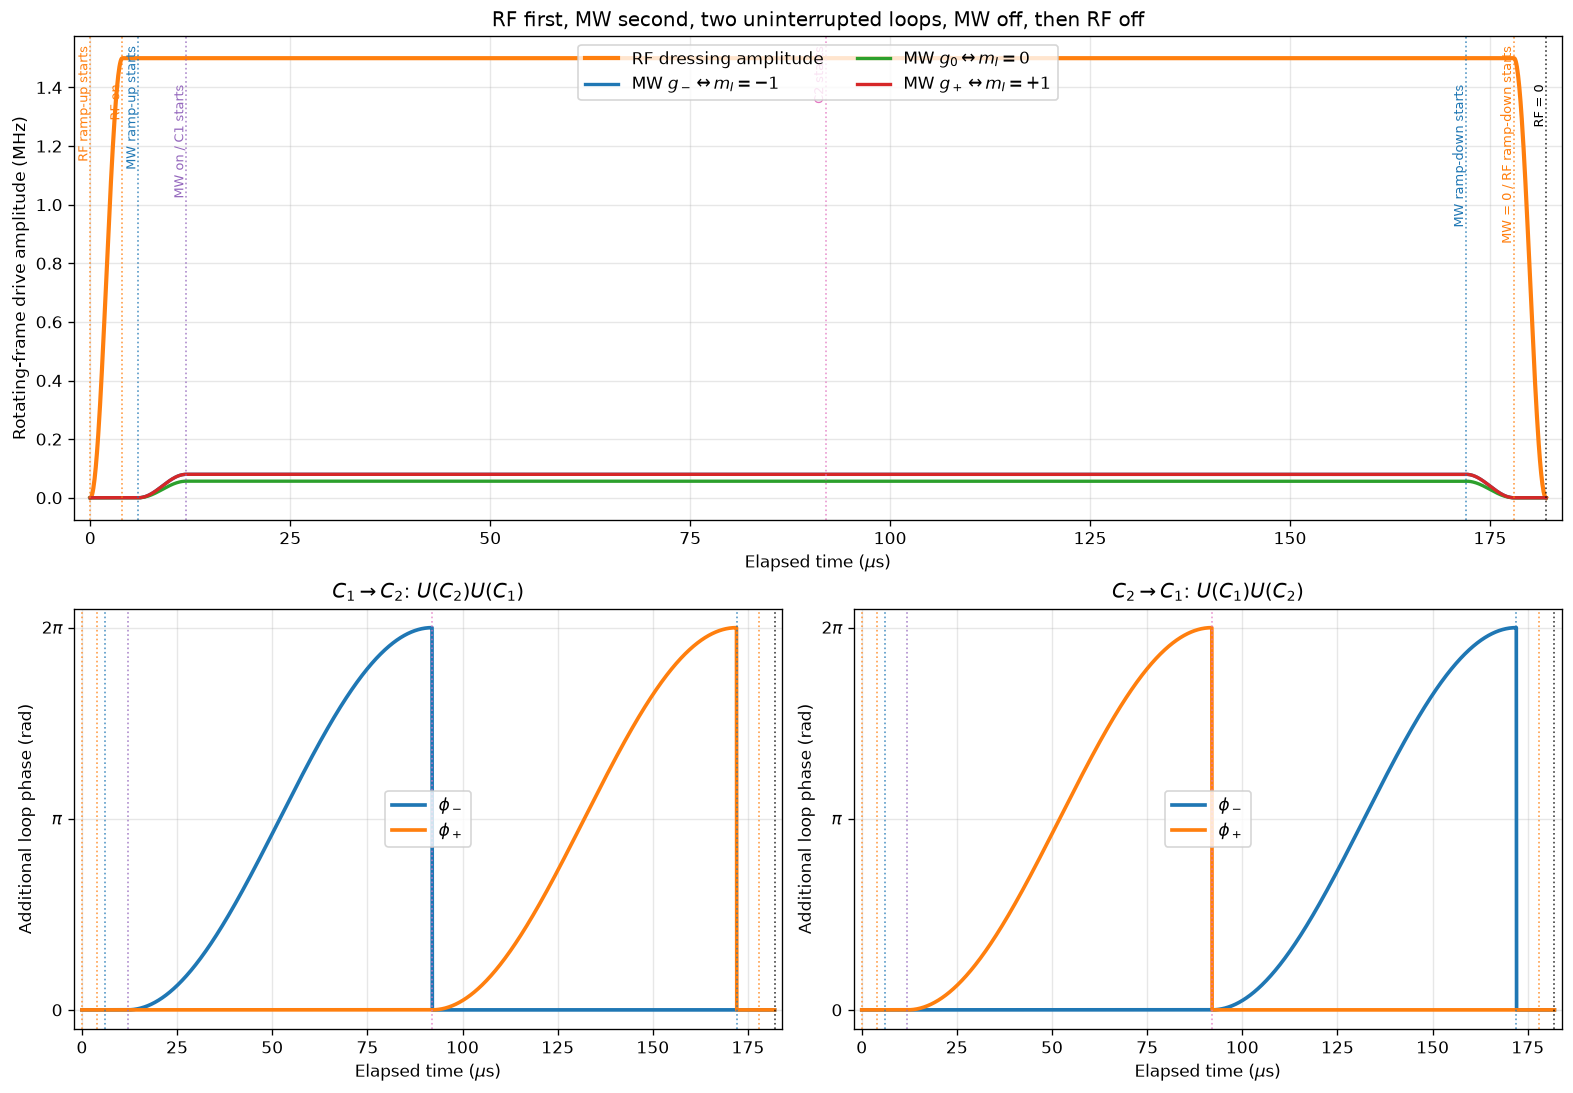

In [16]:
# -----------------------------------------------------------------------------
# C. Plot the complete RF/MW amplitude schedule and both phase-loop orders
# -----------------------------------------------------------------------------
loop_control_times_us = np.linspace(0.0, loop_sequence_duration_us, 2401)
rf_loop_amplitude_mhz = rf_rabi_mhz * rf_loop_envelope(loop_control_times_us)
mw_loop_envelopes_mhz = np.array([
    amplitude_mhz * mw_loop_envelope(loop_control_times_us)
    for amplitude_mhz in mw_loop_bare_amplitudes_mhz
])

fig = plt.figure(figsize=(13, 9), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=(1.15, 1.0))
ax_envelopes = fig.add_subplot(grid[0, :])
ax_phase_C2C1 = fig.add_subplot(grid[1, 0])
ax_phase_C1C2 = fig.add_subplot(grid[1, 1], sharey=ax_phase_C2C1)

ax_envelopes.plot(
    loop_control_times_us,
    rf_loop_amplitude_mhz,
    color="tab:orange",
    lw=2.5,
    label="RF dressing amplitude",
)
for leg_envelope, label, color in zip(
    mw_loop_envelopes_mhz,
    (r"MW $g_-\leftrightarrow m_I=-1$", r"MW $g_0\leftrightarrow m_I=0$", r"MW $g_+\leftrightarrow m_I=+1$"),
    ("tab:blue", "tab:green", "tab:red"),
):
    ax_envelopes.plot(loop_control_times_us, leg_envelope, lw=2.0, color=color, label=label)
mark_loop_sequence_events(ax_envelopes, ("C1", "C2"), annotate=True)
ax_envelopes.set(
    xlim=(-2.0, loop_sequence_duration_us + 2.0),
    xlabel=r"Elapsed time ($\mu$s)",
    ylabel="Rotating-frame drive amplitude (MHz)",
    title="RF first, MW second, two uninterrupted loops, MW off, then RF off",
)
ax_envelopes.legend(ncol=2, loc="upper center")

for ax, loop_order, title in (
    (ax_phase_C2C1, ("C1", "C2"), r"$C_1\rightarrow C_2$: $U(C_2)U(C_1)$"),
    (ax_phase_C1C2, ("C2", "C1"), r"$C_2\rightarrow C_1$: $U(C_1)U(C_2)$"),
):
    phase_values = np.array([
        loop_phase_vector(time_us, loop_order) for time_us in loop_control_times_us
    ])
    ax.plot(loop_control_times_us, phase_values[:, 0], lw=2.2, label=r"$\phi_-$")
    ax.plot(loop_control_times_us, phase_values[:, 2], lw=2.2, label=r"$\phi_+$")
    mark_loop_sequence_events(ax, loop_order, annotate=False)
    ax.set(
        xlim=(-2.0, loop_sequence_duration_us + 2.0),
        xlabel=r"Elapsed time ($\mu$s)",
        ylabel="Additional loop phase (rad)",
        yticks=[0.0, np.pi, 2.0 * np.pi],
        yticklabels=["0", r"$\pi$", r"$2\pi$"],
        title=title,
    )
    ax.legend()

plt.show()


#### Reading the complete control schedule

**How the figure was generated.** The upper panel evaluates the smooth RF and MW envelopes over the full $182\,\mu\mathrm{s}$ sequence. Vertical markers identify every switching or loop event. The lower panels evaluate Equation (10) on the active MW leg and demonstrate that changing the loop order changes only the chronology of $\phi_-$ and $\phi_+$; the amplitude schedule is identical.

**Physical intuition.** The RF reaches its plateau before any MW field is applied, so the $m_s=-1$ eigenbasis is already dressed. The MW fields then open the tripod bright–dark gap. Their amplitudes stay constant while each phase winds through $2\pi$, including across the boundary between the loops. After both windings, the MW gap is closed smoothly before the RF basis is removed.


In [17]:
# -----------------------------------------------------------------------------
# D. Propagate both chronological loop orders with QuaCCAToo PulsedSim
# -----------------------------------------------------------------------------
loop_population_observables = [
    P_g_minus,
    P_g_zero,
    P_g_plus,
    P_excited,
    P_higher_excited_total,
    P_ground_total,
    P_tripod,
    P_all_states,
]
loop_population_labels = (
    r"$P_{g_-}$",
    r"$P_{g_0}$",
    r"$P_{g_+}$",
    r"$P_e$",
    r"$P_{e_0}+P_{e_+}$",
    r"$P_G$",
    r"$P_{g_-}+P_{g_0}+P_{g_+}+P_e$",
    r"$P_{\rm all}$",
)


def run_rotating_frame_loop_order(loop_order, reporting_step_us=0.5):
    """Run the complete RF–MW–loops–MW-off–RF-off sequence.

    Parameters
    ----------
    loop_order : tuple of str
        Chronological pair ('C1','C2') or ('C2','C1').
    reporting_step_us : float
        Positive interval between stored population samples in microseconds.

    Returns
    -------
    dict
        Contains the loop order, reporting times, an (N,8) population array,
        and the final nine-state ket. The population columns follow
        `loop_population_labels` and have the physical meanings requested above.
    """
    if reporting_step_us <= 0.0:
        raise ValueError("reporting_step_us must be positive")

    system = QSys(
        H0=H_loop_static_mhz,
        rho0=loop_order_initial_state,
        observable=None,
        units_H0="MHz",
    )
    experiment = PulsedSim(system)
    shapes = make_loop_control_shapes(loop_order)

    number_of_intervals = int(np.ceil(loop_sequence_duration_us / reporting_step_us))
    reporting_times_us = np.linspace(
        0.0,
        loop_sequence_duration_us,
        number_of_intervals + 1,
    )
    populations = np.empty(
        (len(reporting_times_us), len(loop_population_observables)),
        dtype=float,
    )
    populations[0] = [
        float(np.real(expect(observable, experiment.rho)))
        for observable in loop_population_observables
    ]

    for time_index in range(1, len(reporting_times_us)):
        duration_us = float(reporting_times_us[time_index] - reporting_times_us[time_index - 1])
        experiment.add_pulse(
            duration=duration_us,
            h1=loop_control_operators,
            pulse_shape=shapes,
            pulse_params={},
            time_steps=4,
            options={"nsteps": 100000, "atol": 1e-10, "rtol": 1e-9},
        )
        populations[time_index] = [
            float(np.real(expect(observable, experiment.rho)))
            for observable in loop_population_observables
        ]

    assert np.allclose(populations[:, 7], 1.0, atol=1e-7)
    return {
        "order": tuple(loop_order),
        "times_us": reporting_times_us,
        "populations": populations,
        "final_state": experiment.rho.copy(),
    }


loop_result_C2C1 = run_rotating_frame_loop_order(
    ("C1", "C2"),
    loop_reporting_step_us,
)
loop_result_C1C2 = run_rotating_frame_loop_order(
    ("C2", "C1"),
    loop_reporting_step_us,
)

for result in (loop_result_C2C1, loop_result_C1C2):
    populations = result["populations"]
    print("Chronological loop order:", result["order"])
    print("  maximum normalization error:", np.max(np.abs(populations[:, 7] - 1.0)))
    print("  maximum selected-ancilla population:", np.max(populations[:, 3]))
    print("  maximum higher-dressed population:", np.max(populations[:, 4]))
    print("  final requested populations:", populations[-1])


Chronological loop order: ('C1', 'C2')
  maximum normalization error: 8.881784197001252e-16
  maximum selected-ancilla population: 0.07109765207316049
  maximum higher-dressed population: 0.0013479868044767936
  final requested populations: [4.83787647e-01 4.64864218e-01 4.97471728e-02 1.60095962e-03
 2.81635651e-09 9.98399038e-01 9.99999997e-01 1.00000000e+00]
Chronological loop order: ('C2', 'C1')
  maximum normalization error: 6.661338147750939e-16
  maximum selected-ancilla population: 0.03519356007343313
  maximum higher-dressed population: 0.0013468784598436772
  final requested populations: [1.32553758e-01 1.72475544e-01 6.93421500e-01 1.54919444e-03
 3.25496836e-09 9.98450802e-01 9.99999997e-01 1.00000000e+00]


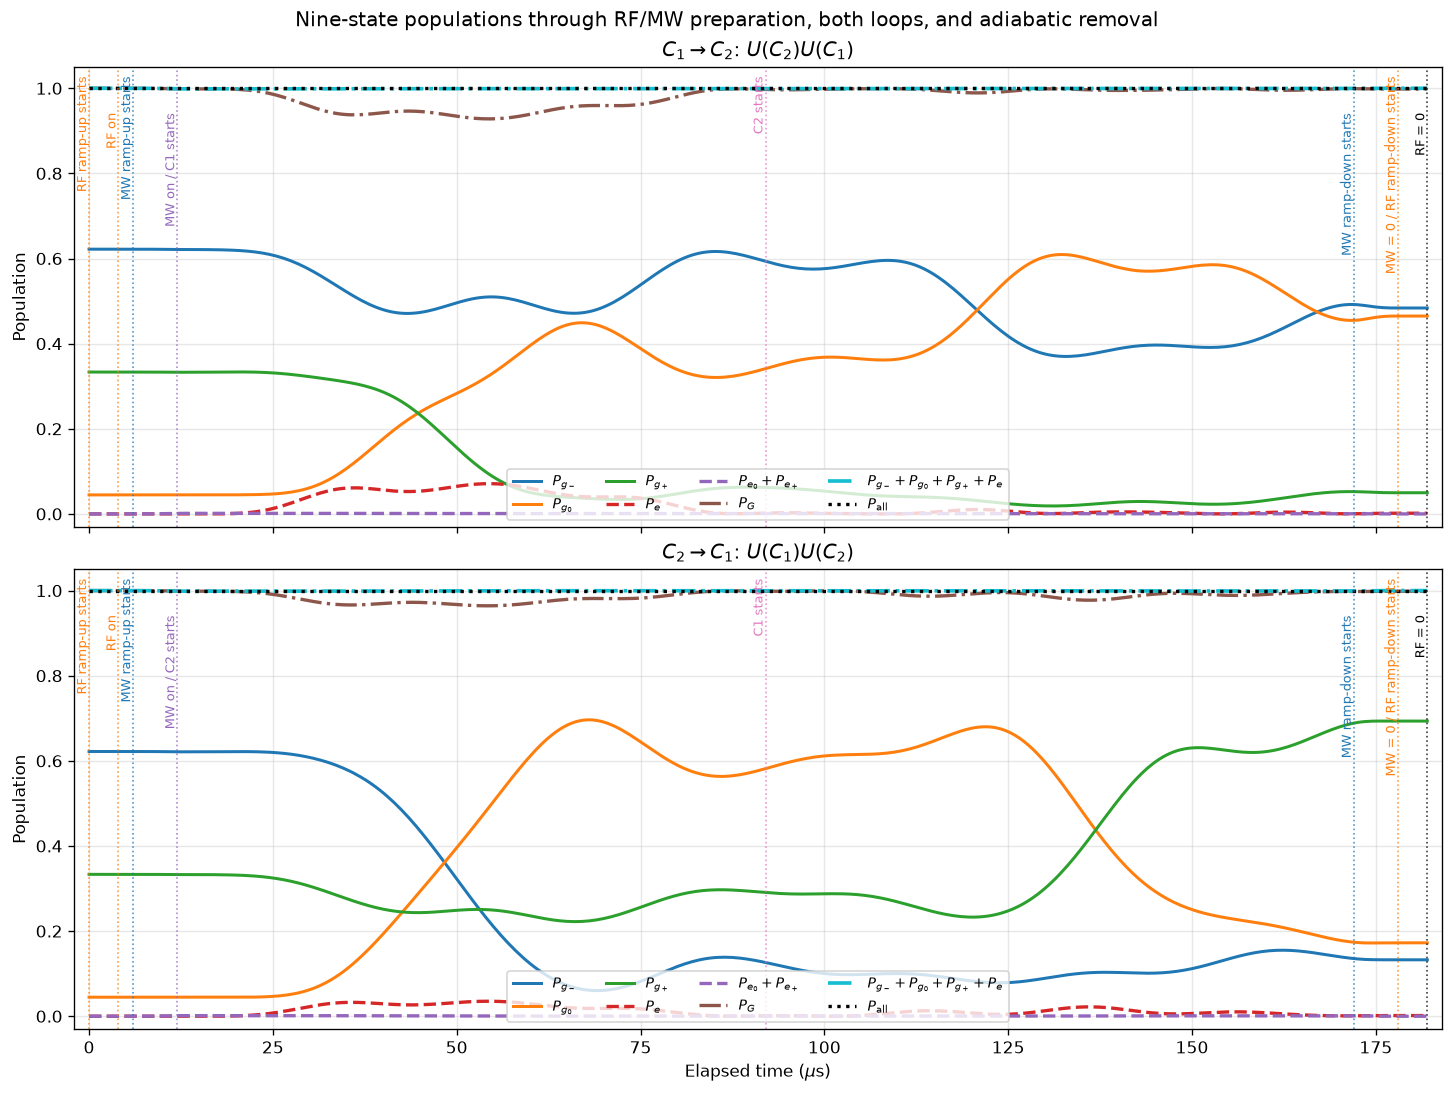

Final C1 -> C2 populations: [4.83787647e-01 4.64864218e-01 4.97471728e-02 1.60095962e-03
 2.81635651e-09 9.98399038e-01 9.99999997e-01 1.00000000e+00]
Final C2 -> C1 populations: [1.32553758e-01 1.72475544e-01 6.93421500e-01 1.54919444e-03
 3.25496836e-09 9.98450802e-01 9.99999997e-01 1.00000000e+00]
Final ground-state population-order contrast: 0.7894130862073846


In [20]:
# -----------------------------------------------------------------------------
# E. Plot every requested population with all pulse/loop event markers
# -----------------------------------------------------------------------------
population_colors = (
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:cyan",
    "black",
)
population_styles = ("-", "-", "-", "--", "--", "-.", "-.", ":")
population_widths = (1.8, 1.8, 1.8, 2.0, 2.0, 2.0, 2.2, 2.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True, sharey=True, constrained_layout=True)
for ax, result, title in (
    (axes[0], loop_result_C2C1, r"$C_1\rightarrow C_2$: $U(C_2)U(C_1)$"),
    (axes[1], loop_result_C1C2, r"$C_2\rightarrow C_1$: $U(C_1)U(C_2)$"),
):
    times_us = result["times_us"]
    populations = result["populations"]
    for column, (label, color, style, width) in enumerate(zip(
        loop_population_labels,
        population_colors,
        population_styles,
        population_widths,
    )):
        ax.plot(
            times_us,
            populations[:, column],
            color=color,
            ls=style,
            lw=width,
            label=label,
        )
    mark_loop_sequence_events(ax, result["order"], annotate=True)
    ax.set(
        xlim=(-2.0, loop_sequence_duration_us + 2.0),
        ylim=(-0.03, 1.05),
        ylabel="Population",
        title=title,
    )
    ax.legend(ncol=4, fontsize=8.5, loc="lower center")

axes[1].set_xlabel(r"Elapsed time ($\mu$s)")
fig.suptitle("Nine-state populations through RF/MW preparation, both loops, and adiabatic removal")
plt.show()

final_populations_C2C1 = loop_result_C2C1["populations"][-1]
final_populations_C1C2 = loop_result_C1C2["populations"][-1]
print("Final C1 -> C2 populations:", final_populations_C2C1)
print("Final C2 -> C1 populations:", final_populations_C1C2)
print(
    "Final ground-state population-order contrast:",
    np.linalg.norm(final_populations_C2C1[:3] - final_populations_C1C2[:3]),
)


#### Reading the loop-order population plots

**How the plots were generated.** A sequential QuaCCAToo `PulsedSim` object carries the same nine-state ket through every $0.5\,\mu\mathrm{s}$ reporting interval. Expectation values are recorded without projective measurement, so the event markers do not collapse the state. The plotted quantities are the three individual ground populations, the selected ancilla population, the combined $|e_0\rangle/|e_+\rangle$ population, total ground population $P_G$, total four-state tripod population, and the complete nine-state trace.

**Final comparison.** For $C_1\rightarrow C_2$, the final ground populations are approximately $[0.484,0.465,0.050]$ with $P_e=1.60\times10^{-3}$. For $C_2\rightarrow C_1$, they are $[0.133,0.172,0.693]$ with $P_e=1.55\times10^{-3}$. The Euclidean contrast between the two final ground-population vectors is $0.789$, even though both sequences use the same envelopes and return all programmed phases to zero.

**Physical intuition.** During RF preparation the initial ground state is unchanged because the RF acts only in the $m_s=-1$ manifold. The MW ramp establishes the dark/bright structure, after which the moving dark basis redistributes the three ground-state populations while keeping the selected-ancilla population comparatively small. Reversing $C_1$ and $C_2$ changes the final ground-state redistribution because the two geometric operations do not commute. The MW and RF ramp-down stages map the final logical state to a drive-free readout point without interrupting either phase loop.


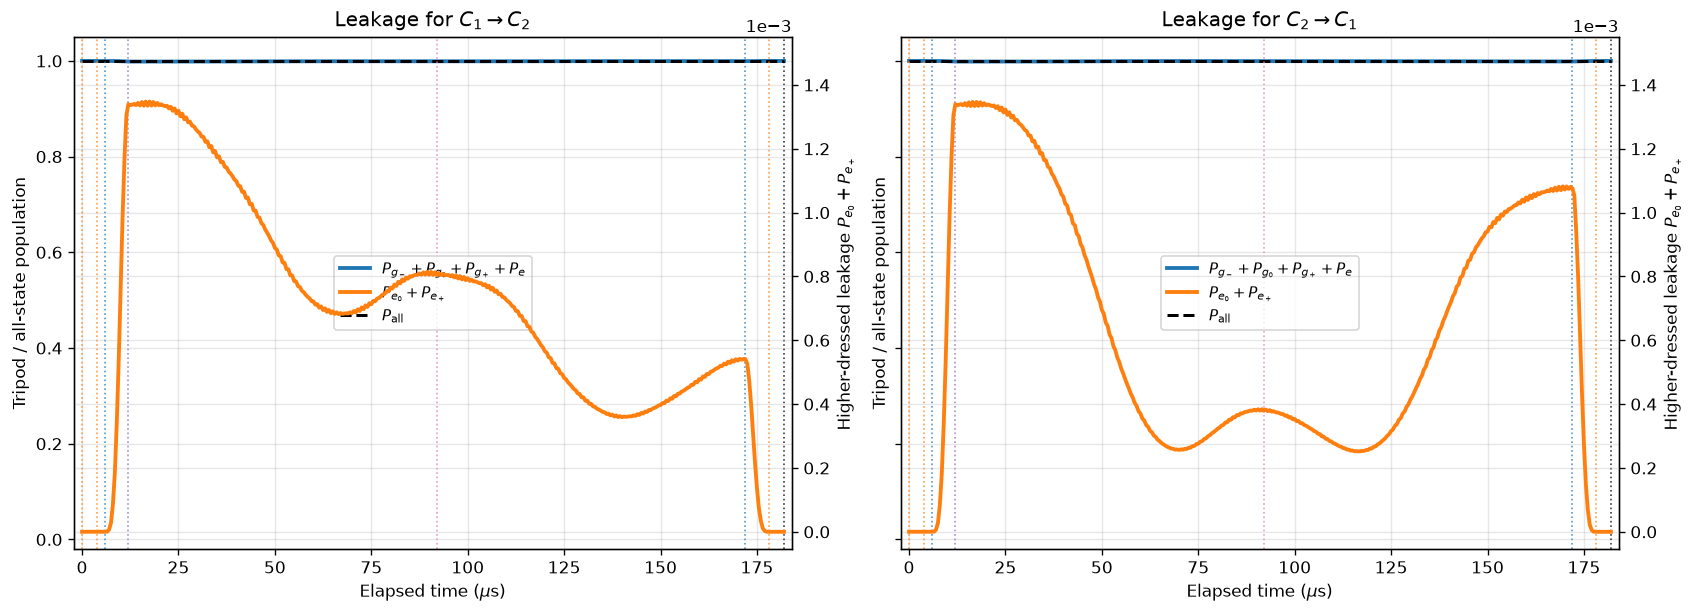

('C1', 'C2') max higher-dressed leakage = 0.0013479868044767936 ; max population outside tripod plus dressed ms=-1 manifold = 4.935288289154016e-16
('C2', 'C1') max higher-dressed leakage = 0.0013468784598436772 ; max population outside tripod plus dressed ms=-1 manifold = 5.184925839368804e-16


In [19]:
# -----------------------------------------------------------------------------
# F. Isolate leakage from the intended four-state tripod into e0 and e+
# -----------------------------------------------------------------------------
maximum_higher_dressed_population = max(
    np.max(loop_result_C2C1["populations"][:, 4]),
    np.max(loop_result_C1C2["populations"][:, 4]),
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, result, title in (
    (axes[0], loop_result_C2C1, r"Leakage for $C_1\rightarrow C_2$"),
    (axes[1], loop_result_C1C2, r"Leakage for $C_2\rightarrow C_1$"),
):
    times_us = result["times_us"]
    populations = result["populations"]

    tripod_line = ax.plot(
        times_us,
        populations[:, 6],
        lw=2.3,
        color="tab:blue",
        label=r"$P_{g_-}+P_{g_0}+P_{g_+}+P_e$",
    )[0]
    all_state_line = ax.plot(
        times_us,
        populations[:, 7],
        lw=1.8,
        ls="--",
        color="black",
        label=r"$P_{\rm all}$",
    )[0]

    # The higher-branch leakage is roughly three orders of magnitude smaller
    # than the normalized tripod population, so give it a dedicated right axis.
    leakage_axis = ax.twinx()
    leakage_line = leakage_axis.plot(
        times_us,
        populations[:, 4],
        lw=2.3,
        color="tab:orange",
        label=r"$P_{e_0}+P_{e_+}$",
    )[0]

    mark_loop_sequence_events(ax, result["order"], annotate=False)
    ax.set(
        xlim=(-2.0, loop_sequence_duration_us + 2.0),
        ylim=(-0.02, 1.05),
        xlabel=r"Elapsed time ($\mu$s)",
        ylabel="Tripod / all-state population",
        title=title,
    )
    leakage_axis.set(
        ylim=(-0.04 * maximum_higher_dressed_population, 1.15 * maximum_higher_dressed_population),
        ylabel=r"Higher-dressed leakage $P_{e_0}+P_{e_+}$",
    )
    leakage_axis.ticklabel_format(axis="y", style="sci", scilimits=(-3, -3))
    ax.legend(
        [tripod_line, leakage_line, all_state_line],
        [line.get_label() for line in (tripod_line, leakage_line, all_state_line)],
        fontsize=9,
        loc="center",
    )

plt.show()

for result in (loop_result_C2C1, loop_result_C1C2):
    populations = result["populations"]
    spectator_population = populations[:, 7] - populations[:, 6] - populations[:, 4]
    print(
        result["order"],
        "max higher-dressed leakage =",
        np.max(populations[:, 4]),
        "; max population outside tripod plus dressed ms=-1 manifold =",
        np.max(np.abs(spectator_population)),
    )


#### Reading the loop-order leakage plots

**How the plots were generated.** The blue curve is the intended four-state tripod population, the orange curve is the combined population in the unwanted middle and highest RF-dressed branches, and the dashed black curve verifies normalization over all nine states. The same RF/MW and loop-event times marked in the population figure are shown here as vertical lines. Because the leakage is about three orders of magnitude smaller than the normalized tripod population, the orange curve uses the right-hand population axis.

**Numerical result.** The maximum combined $P_{e_0}+P_{e_+}$ is $1.348\times10^{-3}$ for $C_1\rightarrow C_2$ and $1.347\times10^{-3}$ for the reversed order. Population outside the tripod plus the complete dressed $m_s=-1$ manifold stays below $5.2\times10^{-16}$, so the retained $m_s=+1$ spectator manifold is not populated at visible numerical precision.

**Physical intuition.** Population in $|e_0\rangle$ or $|e_+\rangle$ arises because each physical MW leg couples to a bare $m_s=-1$ state, which contains components of all three RF-dressed branches. The RF gap makes the unwanted branches off-resonant, while the smooth ramps and slow phase loops suppress nonadiabatic transfer. Any gap between the sum of the blue and orange curves and $P_{\rm all}$ would identify occupation of the three retained $m_s=+1$-like spectator states rather than dressed-manifold leakage.
